# Tarea 3: Polars — NYC Taxi Trip Duration
**Partes 1,2, 3: Análisis Exploratorio, Ingeniería de Características, Machine Learning**

Dataset: [NYC Taxi Trip Duration](https://www.kaggle.com/competitions/nyc-taxi-trip-duration)

**Variable objetivo:** `trip_duration` (segundos)

## Instalación e importaciones

In [1]:
!pip install polars matplotlib seaborn -q

In [2]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print(f'Polars version: {pl.__version__}')

Polars version: 1.35.2



# Parte 1: Análisis Exploratorio

Todo el análisis se realiza exclusivamente con **Polars**.

## 1.1 Carga del dataset (Lazy Execution)

In [3]:
# Ajusta la ruta si es necesario
DATA_PATH = '/content/train.csv'

# Lectura con LazyFrame para mayor eficiencia
lf = pl.scan_csv(DATA_PATH)

# Materializamos una vez para exploración
df = lf.collect()

print(f'Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}')
print(f'\nEsquema de tipos:')
print(df.schema)

Filas: 609,990  |  Columnas: 11

Esquema de tipos:
Schema({'id': String, 'vendor_id': Int64, 'pickup_datetime': String, 'dropoff_datetime': String, 'passenger_count': Int64, 'pickup_longitude': Float64, 'pickup_latitude': Float64, 'dropoff_longitude': Float64, 'dropoff_latitude': Float64, 'store_and_fwd_flag': String, 'trip_duration': Int64})


## 1.2 Descripción de variables

| Columna | Tipo | Descripción |
|---|---|---|
| `id` | str | Identificador único del viaje |
| `vendor_id` | int | Proveedor del taxi (1 o 2) |
| `pickup_datetime` | str | Fecha y hora de recogida |
| `dropoff_datetime` | str | Fecha y hora de bajada |
| `passenger_count` | int | Número de pasajeros |
| `pickup_longitude` | float | Longitud de recogida |
| `pickup_latitude` | float | Latitud de recogida |
| `dropoff_longitude` | float | Longitud de destino |
| `dropoff_latitude` | float | Latitud de destino |
| `store_and_fwd_flag` | str | ¿El viaje fue almacenado offline? (Y/N) |
| `trip_duration` | int | **Variable objetivo**: duración en segundos |

## 1.3 Vista previa

In [4]:
df.head(5)

id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
str,i64,str,str,i64,f64,f64,f64,f64,str,i64
"""id2875421""",2,"""2016-03-14 17:24:55""","""2016-03-14 17:32:30""",1,-73.982155,40.767937,-73.96463,40.765602,"""N""",455
"""id2377394""",1,"""2016-06-12 00:43:35""","""2016-06-12 00:54:38""",1,-73.980415,40.738564,-73.999481,40.731152,"""N""",663
"""id3858529""",2,"""2016-01-19 11:35:24""","""2016-01-19 12:10:48""",1,-73.979027,40.763939,-74.005333,40.710087,"""N""",2124
"""id3504673""",2,"""2016-04-06 19:32:31""","""2016-04-06 19:39:40""",1,-74.01004,40.719971,-74.012268,40.706718,"""N""",429
"""id2181028""",2,"""2016-03-26 13:30:55""","""2016-03-26 13:38:10""",1,-73.973053,40.793209,-73.972923,40.78252,"""N""",435


## 1.4 Estadísticas descriptivas

In [5]:
# Estadísticas de columnas numéricas
numericas = ['passenger_count', 'pickup_longitude', 'pickup_latitude',
             'dropoff_longitude', 'dropoff_latitude', 'trip_duration']

desc = df.select(numericas).describe()
print(desc)

shape: (9, 7)
┌────────────┬──────────────┬──────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
│ statistic  ┆ passenger_co ┆ pickup_longi ┆ pickup_lati ┆ dropoff_lon ┆ dropoff_lat ┆ trip_durati │
│ ---        ┆ unt          ┆ tude         ┆ tude        ┆ gitude      ┆ itude       ┆ on          │
│ str        ┆ ---          ┆ ---          ┆ ---         ┆ ---         ┆ ---         ┆ ---         │
│            ┆ f64          ┆ f64          ┆ f64         ┆ f64         ┆ f64         ┆ f64         │
╞════════════╪══════════════╪══════════════╪═════════════╪═════════════╪═════════════╪═════════════╡
│ count      ┆ 609989.0     ┆ 609989.0     ┆ 609989.0    ┆ 609989.0    ┆ 609989.0    ┆ 609989.0    │
│ null_count ┆ 1.0          ┆ 1.0          ┆ 1.0         ┆ 1.0         ┆ 1.0         ┆ 1.0         │
│ mean       ┆ 1.663194     ┆ -73.973538   ┆ 40.750972   ┆ -73.973398  ┆ 40.751824   ┆ 951.046512  │
│ std        ┆ 1.31243      ┆ 0.039979     ┆ 0.033277    ┆ 0.039407    ┆ 0.03

In [6]:
# Resumen adicional: min, max, percentiles de trip_duration
df.select([
    pl.col('trip_duration').min().alias('min_seg'),
    pl.col('trip_duration').quantile(0.25).alias('q25_seg'),
    pl.col('trip_duration').median().alias('mediana_seg'),
    pl.col('trip_duration').quantile(0.75).alias('q75_seg'),
    pl.col('trip_duration').max().alias('max_seg'),
    pl.col('trip_duration').mean().alias('media_seg'),
    pl.col('trip_duration').std().alias('std_seg'),
])

min_seg,q25_seg,mediana_seg,q75_seg,max_seg,media_seg,std_seg
i64,f64,f64,f64,i64,f64,f64
1,397.0,662.0,1075.0,1939736,951.046512,3979.545597


## 1.5 Análisis de valores faltantes

In [7]:
nulos = df.select([
    pl.col(c).null_count().alias(c) for c in df.columns
]).unpivot(variable_name='columna', value_name='nulos')

nulos = nulos.with_columns(
    (pl.col('nulos') / df.shape[0] * 100).round(2).alias('pct_nulos')
)
print(nulos)
print('\n→ El dataset NYC Taxi no tiene valores nulos en la mayoría de columnas.')

shape: (11, 3)
┌────────────────────┬───────┬───────────┐
│ columna            ┆ nulos ┆ pct_nulos │
│ ---                ┆ ---   ┆ ---       │
│ str                ┆ u32   ┆ f64       │
╞════════════════════╪═══════╪═══════════╡
│ id                 ┆ 0     ┆ 0.0       │
│ vendor_id          ┆ 0     ┆ 0.0       │
│ pickup_datetime    ┆ 0     ┆ 0.0       │
│ dropoff_datetime   ┆ 1     ┆ 0.0       │
│ passenger_count    ┆ 1     ┆ 0.0       │
│ …                  ┆ …     ┆ …         │
│ pickup_latitude    ┆ 1     ┆ 0.0       │
│ dropoff_longitude  ┆ 1     ┆ 0.0       │
│ dropoff_latitude   ┆ 1     ┆ 0.0       │
│ store_and_fwd_flag ┆ 1     ┆ 0.0       │
│ trip_duration      ┆ 1     ┆ 0.0       │
└────────────────────┴───────┴───────────┘

→ El dataset NYC Taxi no tiene valores nulos en la mayoría de columnas.


## 1.6 Distribución de la variable objetivo (`trip_duration`)

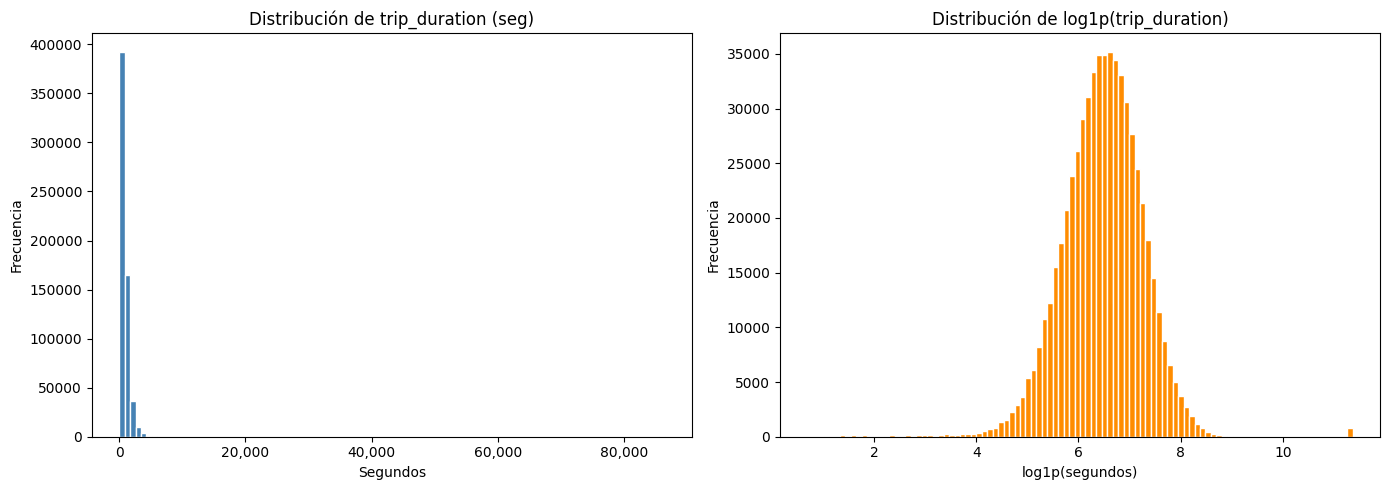

La distribución original está muy sesgada a la derecha → conviene usar log1p como target.


In [8]:
# Filtrar outliers extremos para la visualización (> 24 horas = 86400 s)
dur = df.filter(pl.col('trip_duration') <= 86400)['trip_duration'].to_numpy()
dur_log = np.log1p(dur)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(dur, bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de trip_duration (seg)')
axes[0].set_xlabel('Segundos')
axes[0].set_ylabel('Frecuencia')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].hist(dur_log, bins=100, color='darkorange', edgecolor='white')
axes[1].set_title('Distribución de log1p(trip_duration)')
axes[1].set_xlabel('log1p(segundos)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('dist_trip_duration.png', dpi=150)
plt.show()
print('La distribución original está muy sesgada a la derecha → conviene usar log1p como target.')

## 1.7 Distribución de variables categóricas

In [9]:
# vendor_id
vendor_counts = (
    df.group_by('vendor_id')
    .agg(pl.len().alias('count'))
    .sort('vendor_id')
)
print('Distribución vendor_id:')
print(vendor_counts)

# store_and_fwd_flag
flag_counts = (
    df.group_by('store_and_fwd_flag')
    .agg(pl.len().alias('count'))
    .sort('store_and_fwd_flag')
)
print('\nDistribución store_and_fwd_flag:')
print(flag_counts)

# passenger_count
pass_counts = (
    df.group_by('passenger_count')
    .agg(pl.len().alias('count'))
    .sort('passenger_count')
)
print('\nDistribución passenger_count:')
print(pass_counts)

Distribución vendor_id:
shape: (2, 2)
┌───────────┬────────┐
│ vendor_id ┆ count  │
│ ---       ┆ ---    │
│ i64       ┆ u32    │
╞═══════════╪════════╡
│ 1         ┆ 284025 │
│ 2         ┆ 325965 │
└───────────┴────────┘

Distribución store_and_fwd_flag:
shape: (3, 2)
┌────────────────────┬────────┐
│ store_and_fwd_flag ┆ count  │
│ ---                ┆ ---    │
│ str                ┆ u32    │
╞════════════════════╪════════╡
│ null               ┆ 1      │
│ N                  ┆ 606521 │
│ Y                  ┆ 3468   │
└────────────────────┴────────┘

Distribución passenger_count:
shape: (10, 2)
┌─────────────────┬────────┐
│ passenger_count ┆ count  │
│ ---             ┆ ---    │
│ i64             ┆ u32    │
╞═════════════════╪════════╡
│ null            ┆ 1      │
│ 0               ┆ 18     │
│ 1               ┆ 432334 │
│ 2               ┆ 88108  │
│ 3               ┆ 24963  │
│ 4               ┆ 11789  │
│ 5               ┆ 32732  │
│ 6               ┆ 20042  │
│ 7               ┆

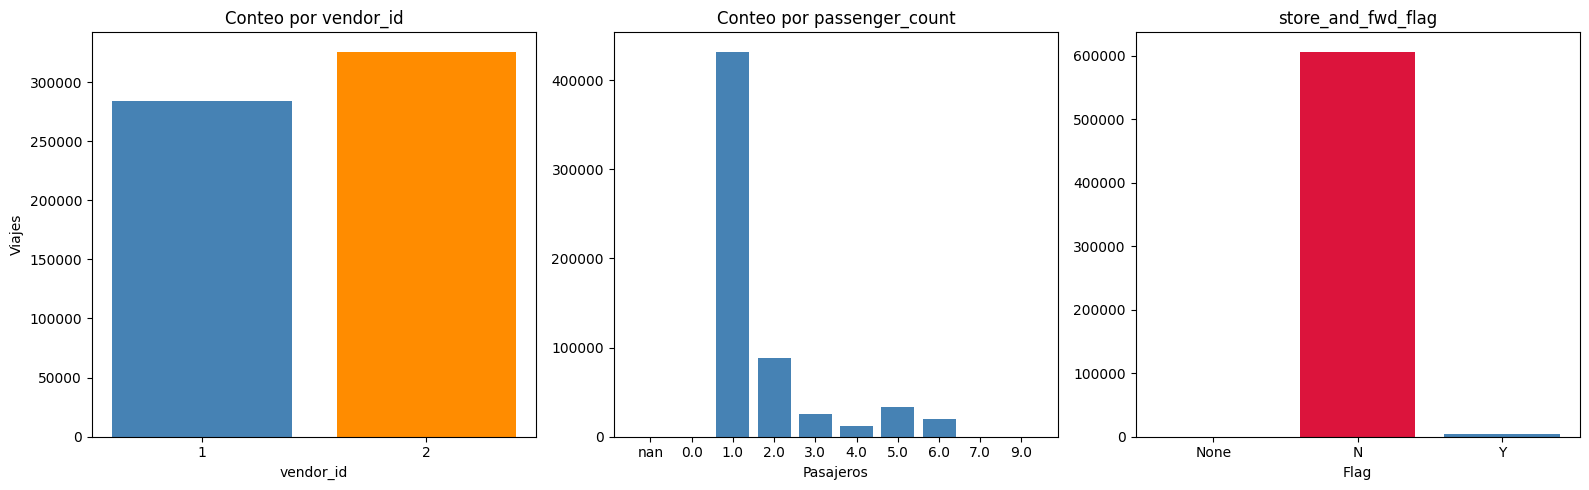

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# vendor_id
v = vendor_counts.to_pandas()
axes[0].bar(v['vendor_id'].astype(str), v['count'], color=['steelblue', 'darkorange'])
axes[0].set_title('Conteo por vendor_id')
axes[0].set_xlabel('vendor_id')
axes[0].set_ylabel('Viajes')

# passenger_count
p = pass_counts.to_pandas()
axes[1].bar(p['passenger_count'].astype(str), p['count'], color='steelblue')
axes[1].set_title('Conteo por passenger_count')
axes[1].set_xlabel('Pasajeros')

# store_and_fwd_flag
f = flag_counts.to_pandas()
axes[2].bar(f['store_and_fwd_flag'].astype(str), f['count'], color=['steelblue', 'crimson'])
axes[2].set_title('store_and_fwd_flag')
axes[2].set_xlabel('Flag')

plt.tight_layout()
plt.savefig('dist_categoricas.png', dpi=150)
plt.show()

## 1.8 Distribución temporal (viajes por hora y día de la semana)

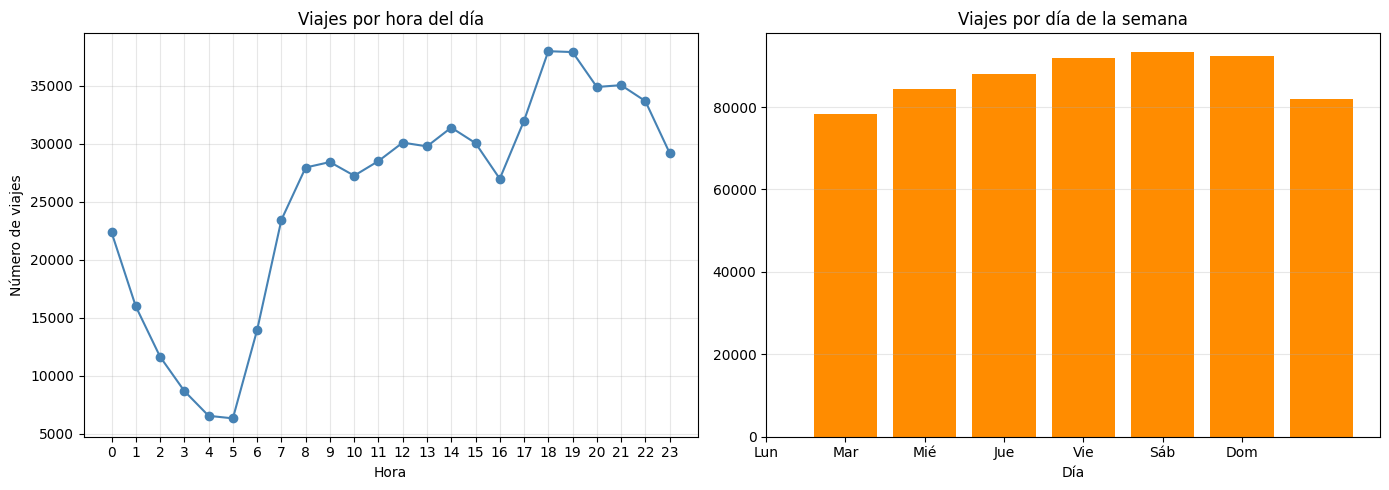

In [14]:
# Parseamos datetime con Polars
df_time = df.with_columns([
    pl.col('pickup_datetime').str.to_datetime('%Y-%m-%d %H:%M:%S', strict=False).alias('pickup_dt')
]).with_columns([
    pl.col('pickup_dt').dt.hour().alias('hora'),
    pl.col('pickup_dt').dt.weekday().alias('dia_semana'),  # 0=Lunes, 6=Domingo
    pl.col('pickup_dt').dt.month().alias('mes'),
])

viajes_hora = (
    df_time.group_by('hora')
    .agg(pl.len().alias('count'))
    .sort('hora')
)

viajes_dia = (
    df_time.group_by('dia_semana')
    .agg(pl.len().alias('count'))
    .sort('dia_semana')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

h = viajes_hora.to_pandas()
axes[0].plot(h['hora'], h['count'], marker='o', color='steelblue')
axes[0].set_title('Viajes por hora del día')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Número de viajes')
axes[0].set_xticks(range(0, 24))
axes[0].grid(True, alpha=0.3)

dias_labels = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
d = viajes_dia.to_pandas()
axes[1].bar(d['dia_semana'], d['count'], color='darkorange')
axes[1].set_title('Viajes por día de la semana')
axes[1].set_xlabel('Día')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(dias_labels)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('viajes_temporal.png', dpi=150)
plt.show()

## 1.9 Análisis de correlaciones

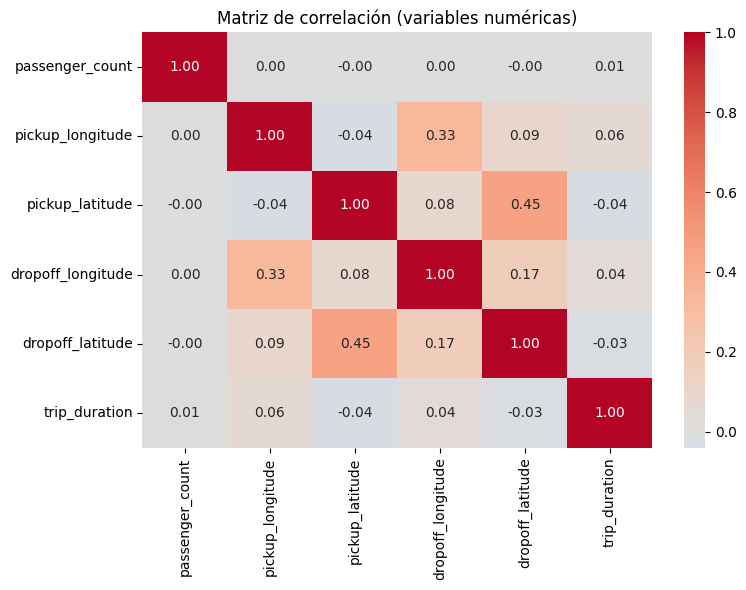


Correlación con trip_duration:
pickup_longitude     0.060751
pickup_latitude     -0.037408
dropoff_longitude    0.035305
dropoff_latitude    -0.026478
passenger_count      0.010652


In [15]:
# Correlación de Pearson entre variables numéricas y trip_duration
cols_corr = ['passenger_count', 'pickup_longitude', 'pickup_latitude',
             'dropoff_longitude', 'dropoff_latitude', 'trip_duration']

corr_matrix = df.select(cols_corr).to_pandas().corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    ax=ax
)
ax.set_title('Matriz de correlación (variables numéricas)')
plt.tight_layout()
plt.savefig('correlacion.png', dpi=150)
plt.show()

# Correlación directa con trip_duration
corr_target = corr_matrix['trip_duration'].drop('trip_duration').sort_values(key=abs, ascending=False)
print('\nCorrelación con trip_duration:')
print(corr_target.to_string())

## 1.10 Duración media por vendor y por hora

In [16]:
# Duración media por vendor
dur_vendor = (
    df.group_by('vendor_id')
    .agg([
        pl.col('trip_duration').mean().alias('duracion_media_seg'),
        pl.col('trip_duration').median().alias('duracion_mediana_seg'),
        pl.len().alias('total_viajes'),
    ])
    .sort('vendor_id')
)
print('Duración por vendor_id:')
print(dur_vendor)

Duración por vendor_id:
shape: (2, 4)
┌───────────┬────────────────────┬──────────────────────┬──────────────┐
│ vendor_id ┆ duracion_media_seg ┆ duracion_mediana_seg ┆ total_viajes │
│ ---       ┆ ---                ┆ ---                  ┆ ---          │
│ i64       ┆ f64                ┆ f64                  ┆ u32          │
╞═══════════╪════════════════════╪══════════════════════╪══════════════╡
│ 1         ┆ 838.852822         ┆ 658.0                ┆ 284025       │
│ 2         ┆ 1048.804556        ┆ 666.0                ┆ 325965       │
└───────────┴────────────────────┴──────────────────────┴──────────────┘


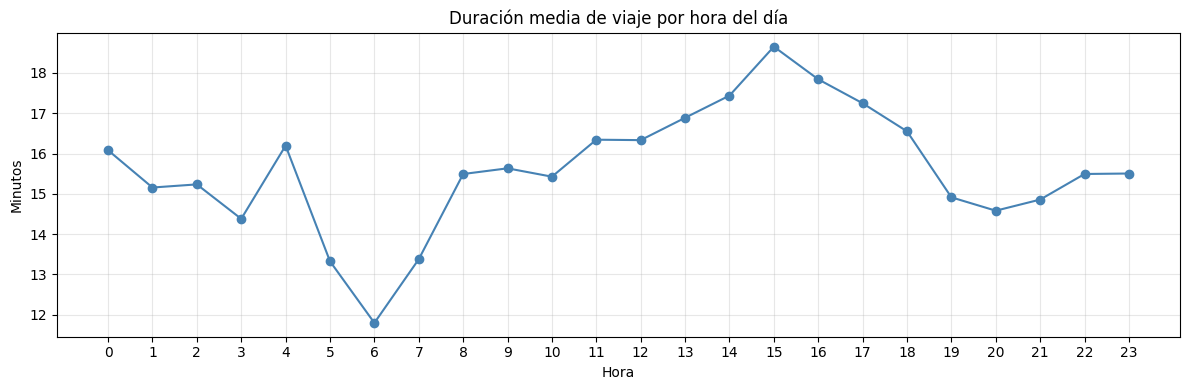

In [17]:
# Duración media por hora
dur_hora = (
    df_time.group_by('hora')
    .agg(pl.col('trip_duration').mean().alias('duracion_media_seg'))
    .sort('hora')
)

h2 = dur_hora.to_pandas()
plt.figure(figsize=(12, 4))
plt.plot(h2['hora'], h2['duracion_media_seg'] / 60, marker='o', color='steelblue')
plt.title('Duración media de viaje por hora del día')
plt.xlabel('Hora')
plt.ylabel('Minutos')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('duracion_por_hora.png', dpi=150)
plt.show()

## 1.11 Detección de outliers en trip_duration

In [18]:
q1 = df['trip_duration'].quantile(0.25)
q3 = df['trip_duration'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df.filter(
    (pl.col('trip_duration') < lower) | (pl.col('trip_duration') > upper)
)

print(f'Q1: {q1:.0f}s  |  Q3: {q3:.0f}s  |  IQR: {iqr:.0f}s')
print(f'Límite inferior: {lower:.0f}s  |  Límite superior: {upper:.0f}s')
print(f'Outliers detectados: {outliers.shape[0]:,} ({outliers.shape[0]/df.shape[0]*100:.2f}%)')

# Outliers extremos (> 24h o duración 0)
extremos = df.filter(
    (pl.col('trip_duration') <= 0) | (pl.col('trip_duration') > 86400)
)
print(f'Outliers extremos (<=0s o >24h): {extremos.shape[0]:,}')

Q1: 397s  |  Q3: 1075s  |  IQR: 678s
Límite inferior: -620s  |  Límite superior: 2092s
Outliers detectados: 30,819 (5.05%)
Outliers extremos (<=0s o >24h): 1



# Parte 2: Ingeniería de Características

Pipeline completo implementado con **Polars (LazyFrame)**.

## 2.1 Tabla de referencia de zonas (join)

Creamos una tabla auxiliar de zonas aproximadas de NYC para simular un join realista.

In [19]:
# Tabla auxiliar: vendor_id → nombre del proveedor
vendor_info = pl.DataFrame({
    'vendor_id': [1, 2],
    'vendor_name': ['Creative Mobile Technologies', 'VeriFone Inc.'],
    'vendor_tier': ['standard', 'premium'],
})

print('Tabla vendor_info:')
print(vendor_info)

Tabla vendor_info:
shape: (2, 3)
┌───────────┬──────────────────────────────┬─────────────┐
│ vendor_id ┆ vendor_name                  ┆ vendor_tier │
│ ---       ┆ ---                          ┆ ---         │
│ i64       ┆ str                          ┆ str         │
╞═══════════╪══════════════════════════════╪═════════════╡
│ 1         ┆ Creative Mobile Technologies ┆ standard    │
│ 2         ┆ VeriFone Inc.                ┆ premium     │
└───────────┴──────────────────────────────┴─────────────┘


## 2.2 Pipeline de transformación completo (LazyFrame)

In [20]:
def haversine_expr(lat1, lon1, lat2, lon2):
    """Fórmula de Haversine en expresiones Polars para calcular distancia en km."""
    R = 6371.0
    dlat = (lat2 - lat1) * np.pi / 180
    dlon = (lon2 - lon1) * np.pi / 180
    a = (
        (dlat / 2).sin() ** 2
        + lat1.radians().cos() * lat2.radians().cos() * (dlon / 2).sin() ** 2
    )
    c = 2 * a.sqrt().arcsin()
    return c * R


pipeline = (
    pl.scan_csv(DATA_PATH)

    # ── 1. FILTRADO DE REGISTROS ─────────────────────────────────────────────
    # Remover viajes con duración inválida o coordenadas fuera de NYC
    .filter(
        (pl.col('trip_duration') > 60)          # mínimo 1 minuto
        & (pl.col('trip_duration') <= 7200)      # máximo 2 horas
        & (pl.col('passenger_count') >= 1)
        & (pl.col('passenger_count') <= 6)
        & pl.col('pickup_longitude').is_between(-74.05, -73.75)
        & pl.col('pickup_latitude').is_between(40.63, 40.85)
        & pl.col('dropoff_longitude').is_between(-74.05, -73.75)
        & pl.col('dropoff_latitude').is_between(40.63, 40.85)
    )

    # ── 2. MANEJO DE DATOS FALTANTES ─────────────────────────────────────────
    .with_columns([
        pl.col('store_and_fwd_flag').fill_null('N'),
        pl.col('passenger_count').fill_null(
            pl.col('passenger_count').median()
        ),
    ])

    # ── 3. TRANSFORMACIÓN DE VARIABLES ────────────────────────────────────────
    # Parseo de fechas
    .with_columns([
        pl.col('pickup_datetime').str.to_datetime('%Y-%m-%d %H:%M:%S').alias('pickup_dt'),
        pl.col('dropoff_datetime').str.to_datetime('%Y-%m-%d %H:%M:%S').alias('dropoff_dt'),
    ])
    # Codificación binaria de flag
    .with_columns([
        (pl.col('store_and_fwd_flag') == 'Y').cast(pl.Int8).alias('store_and_fwd_flag_enc'),
    ])

    # ── 4. CREACIÓN DE NUEVAS CARACTERÍSTICAS ─────────────────────────────────
    .with_columns([
        # Temporales
        pl.col('pickup_dt').dt.hour().alias('pickup_hour'),
        pl.col('pickup_dt').dt.weekday().alias('pickup_weekday'),
        pl.col('pickup_dt').dt.month().alias('pickup_month'),
        pl.col('pickup_dt').dt.day().alias('pickup_day'),

        # ¿Es hora punta? (7-9 AM o 5-7 PM)
        (
            pl.col('pickup_dt').dt.hour().is_between(7, 9)
            | pl.col('pickup_dt').dt.hour().is_between(17, 19)
        ).cast(pl.Int8).alias('es_hora_punta'),

        # ¿Es fin de semana?
        (pl.col('pickup_dt').dt.weekday() >= 5).cast(pl.Int8).alias('es_fin_semana'),

        # ¿Es nocturno? (10 PM - 5 AM)
        (
            pl.col('pickup_dt').dt.hour().is_between(22, 23)
            | pl.col('pickup_dt').dt.hour().is_between(0, 5)
        ).cast(pl.Int8).alias('es_nocturno'),

        # Distancia Haversine (km)
        haversine_expr(
            pl.col('pickup_latitude'),
            pl.col('pickup_longitude'),
            pl.col('dropoff_latitude'),
            pl.col('dropoff_longitude'),
        ).alias('distancia_km'),

        # Diferencia Manhattan de coordenadas
        (
            (pl.col('pickup_longitude') - pl.col('dropoff_longitude')).abs()
            + (pl.col('pickup_latitude') - pl.col('dropoff_latitude')).abs()
        ).alias('delta_coord_manhattan'),

        # Dirección del viaje (azimuth aproximado)
        (
            (pl.col('dropoff_longitude') - pl.col('pickup_longitude'))
            / ((pl.col('dropoff_latitude') - pl.col('pickup_latitude')).abs() + 1e-6)
        ).alias('bearing_aprox'),

        # Variable objetivo transformada
        pl.col('trip_duration').log1p().alias('log_trip_duration'),
    ])

    # ── 5. JOIN con tabla de proveedores ──────────────────────────────────────
    .join(
        vendor_info.lazy(),
        on='vendor_id',
        how='left'
    )

    # ── 6. AGREGACIÓN group_by: velocidad media por hora ──────────────────────
    # (se calcula aparte y se une)
)

print('Pipeline LazyFrame construido. Ejecutando con .collect()...')
df_fe = pipeline.collect()
print(f'Registros después del filtrado: {df_fe.shape[0]:,}')
print(f'Columnas generadas: {df_fe.shape[1]}')
df_fe.head(3)

Pipeline LazyFrame construido. Ejecutando con .collect()...
Registros después del filtrado: 776,974
Columnas generadas: 27


id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_dt,dropoff_dt,store_and_fwd_flag_enc,pickup_hour,pickup_weekday,pickup_month,pickup_day,es_hora_punta,es_fin_semana,es_nocturno,distancia_km,delta_coord_manhattan,bearing_aprox,log_trip_duration,vendor_name,vendor_tier
str,i64,str,str,f64,f64,f64,f64,f64,str,i64,datetime[μs],datetime[μs],i8,i8,i8,i8,i8,i8,i8,i8,f64,f64,f64,f64,str,str
"""id2875421""",2,"""2016-03-14 17:24:55""","""2016-03-14 17:32:30""",1.0,-73.982155,40.767937,-73.96463,40.765602,"""N""",455,2016-03-14 17:24:55,2016-03-14 17:32:30,0,17,1,3,14,1,0,0,1.498521,0.019859,7.503322,6.122493,"""VeriFone Inc.""","""premium"""
"""id2377394""",1,"""2016-06-12 00:43:35""","""2016-06-12 00:54:38""",1.0,-73.980415,40.738564,-73.999481,40.731152,"""N""",663,2016-06-12 00:43:35,2016-06-12 00:54:38,0,0,7,6,12,0,1,1,1.805507,0.026478,-2.571964,6.498282,"""Creative Mobile Technologies""","""standard"""
"""id3858529""",2,"""2016-01-19 11:35:24""","""2016-01-19 12:10:48""",1.0,-73.979027,40.763939,-74.005333,40.710087,"""N""",2124,2016-01-19 11:35:24,2016-01-19 12:10:48,0,11,2,1,19,0,0,0,6.385098,0.080158,-0.48848,7.661527,"""VeriFone Inc.""","""premium"""


## 2.3 Agregación: velocidad media por zona/hora (group_by)

In [21]:
# Velocidad media (km/h) por hora del día
vel_hora = (
    df_fe
    .with_columns([
        (pl.col('distancia_km') / (pl.col('trip_duration') / 3600)).alias('velocidad_kmh')
    ])
    .group_by('pickup_hour')
    .agg([
        pl.col('velocidad_kmh').mean().alias('vel_media_kmh'),
        pl.col('velocidad_kmh').median().alias('vel_mediana_kmh'),
        pl.len().alias('n_viajes'),
    ])
    .sort('pickup_hour')
)

print('Velocidad media por hora:')
print(vel_hora)

# Unir la velocidad media por hora como feature de contexto
df_fe = df_fe.join(
    vel_hora.select(['pickup_hour', 'vel_media_kmh']),
    on='pickup_hour',
    how='left'
)

print(f'\nColumnas finales: {df_fe.shape[1]}')

Velocidad media por hora:
shape: (24, 4)
┌─────────────┬───────────────┬─────────────────┬──────────┐
│ pickup_hour ┆ vel_media_kmh ┆ vel_mediana_kmh ┆ n_viajes │
│ ---         ┆ ---           ┆ ---             ┆ ---      │
│ i8          ┆ f64           ┆ f64             ┆ u32      │
╞═════════════╪═══════════════╪═════════════════╪══════════╡
│ 0           ┆ 17.331167     ┆ 15.869709       ┆ 27938    │
│ 1           ┆ 18.044944     ┆ 16.803642       ┆ 20153    │
│ 2           ┆ 18.526766     ┆ 17.432799       ┆ 14712    │
│ 3           ┆ 19.515592     ┆ 18.282521       ┆ 10914    │
│ 4           ┆ 21.462019     ┆ 20.062782       ┆ 8030     │
│ …           ┆ …             ┆ …               ┆ …        │
│ 19          ┆ 13.467203     ┆ 12.20624        ┆ 48284    │
│ 20          ┆ 14.93392      ┆ 13.599026       ┆ 44651    │
│ 21          ┆ 15.532471     ┆ 14.220699       ┆ 44826    │
│ 22          ┆ 15.763886     ┆ 14.454206       ┆ 42670    │
│ 23          ┆ 16.517898     ┆ 15.053856   

## 2.4 Velocidad media por hora (visualización)

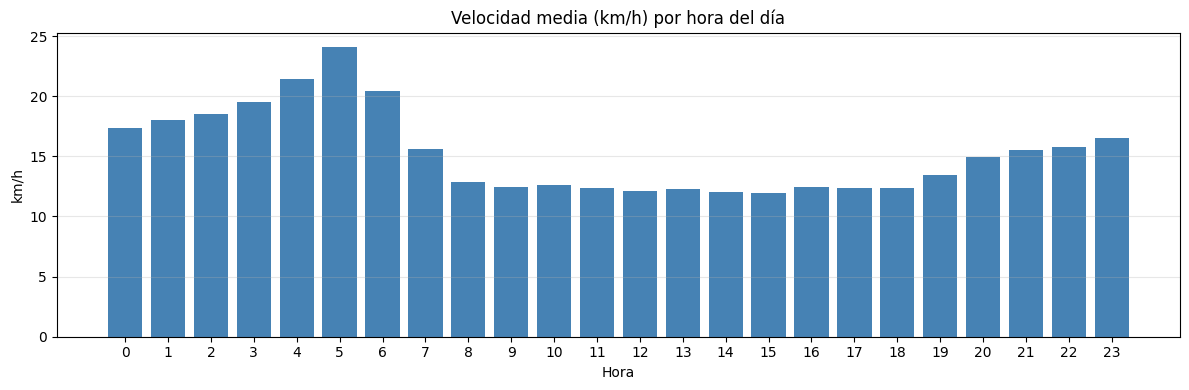

In [22]:
v2 = vel_hora.to_pandas()
plt.figure(figsize=(12, 4))
plt.bar(v2['pickup_hour'], v2['vel_media_kmh'], color='steelblue')
plt.title('Velocidad media (km/h) por hora del día')
plt.xlabel('Hora')
plt.ylabel('km/h')
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('velocidad_por_hora.png', dpi=150)
plt.show()

## 2.5 Distribución de la distancia Haversine

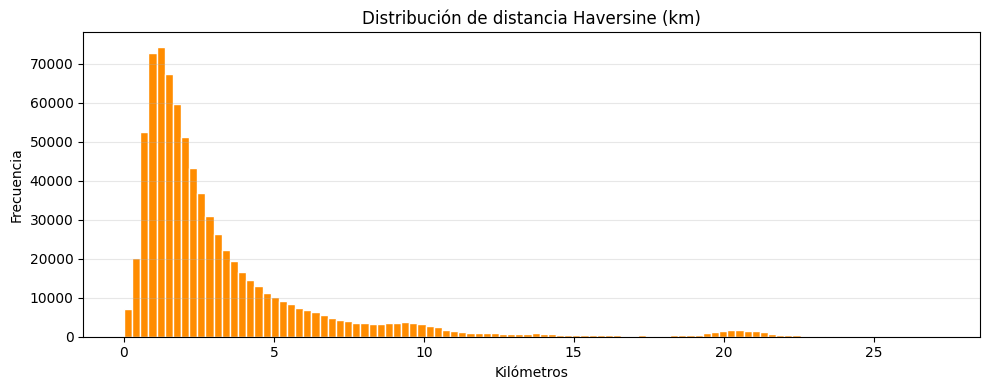

shape: (1, 4)
┌────────┬──────────┬────────────┬───────────┐
│ min_km ┆ media_km ┆ mediana_km ┆ max_km    │
│ ---    ┆ ---      ┆ ---        ┆ ---       │
│ f64    ┆ f64      ┆ f64        ┆ f64       │
╞════════╪══════════╪════════════╪═══════════╡
│ 0.0    ┆ 3.309548 ┆ 2.081866   ┆ 27.191629 │
└────────┴──────────┴────────────┴───────────┘


In [23]:
dist = df_fe.filter(pl.col('distancia_km') < 50)['distancia_km'].to_numpy()

plt.figure(figsize=(10, 4))
plt.hist(dist, bins=100, color='darkorange', edgecolor='white')
plt.title('Distribución de distancia Haversine (km)')
plt.xlabel('Kilómetros')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('dist_distancia_km.png', dpi=150)
plt.show()

print(df_fe.select([
    pl.col('distancia_km').min().alias('min_km'),
    pl.col('distancia_km').mean().alias('media_km'),
    pl.col('distancia_km').median().alias('mediana_km'),
    pl.col('distancia_km').max().alias('max_km'),
]))

## 2.6 Correlación de nuevas features con trip_duration

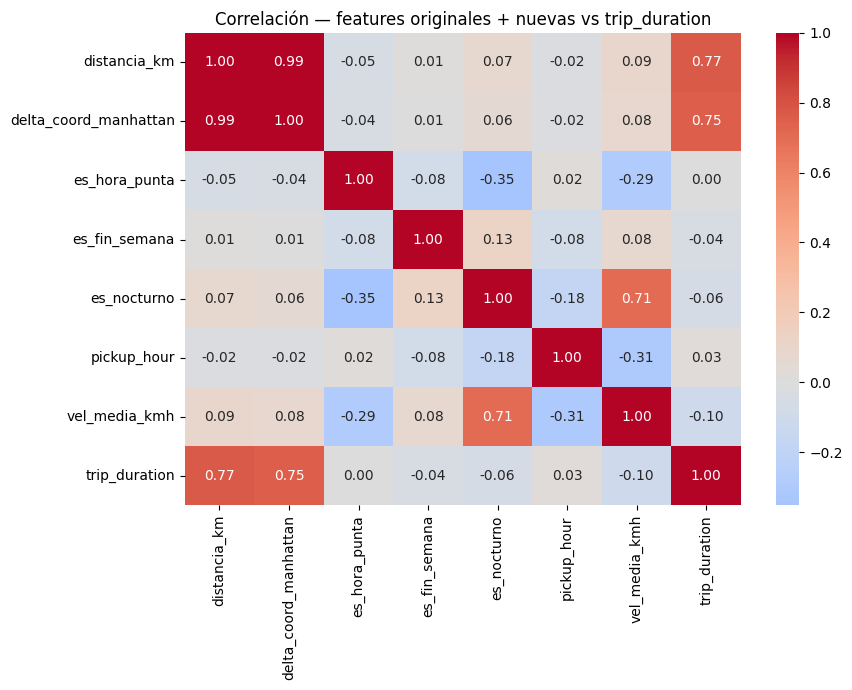


Correlación con trip_duration (nuevas features):
distancia_km             0.770335
delta_coord_manhattan    0.754529
vel_media_kmh           -0.100638
es_nocturno             -0.058092
es_fin_semana           -0.044899
pickup_hour              0.030123
es_hora_punta            0.004102


In [24]:
cols_nuevas = [
    'distancia_km', 'delta_coord_manhattan', 'es_hora_punta',
    'es_fin_semana', 'es_nocturno', 'pickup_hour',
    'vel_media_kmh', 'trip_duration'
]

corr2 = df_fe.select(cols_nuevas).to_pandas().corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr2, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlación — features originales + nuevas vs trip_duration')
plt.tight_layout()
plt.savefig('correlacion_features.png', dpi=150)
plt.show()

# Ranking de correlación con target
corr_target2 = corr2['trip_duration'].drop('trip_duration').sort_values(key=abs, ascending=False)
print('\nCorrelación con trip_duration (nuevas features):')
print(corr_target2.to_string())

## 2.7 Dataset final procesado

In [25]:
# Columnas finales para Machine Learning
feature_cols = [
    'vendor_id', 'passenger_count',
    'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude',
    'store_and_fwd_flag_enc',
    'pickup_hour', 'pickup_weekday', 'pickup_month', 'pickup_day',
    'es_hora_punta', 'es_fin_semana', 'es_nocturno',
    'distancia_km', 'delta_coord_manhattan', 'bearing_aprox',
    'vel_media_kmh',
    'trip_duration', 'log_trip_duration',
]

df_final = df_fe.select(feature_cols)

print(f'Dataset final: {df_final.shape[0]:,} filas × {df_final.shape[1]} columnas')
print('\nEsquema:')
print(df_final.schema)

# Guardar para la Parte 3
df_final.write_csv('nyc_taxi_processed.csv')
print('\n✓ Dataset guardado como nyc_taxi_processed.csv')

Dataset final: 776,974 filas × 20 columnas

Esquema:
Schema({'vendor_id': Int64, 'passenger_count': Float64, 'pickup_longitude': Float64, 'pickup_latitude': Float64, 'dropoff_longitude': Float64, 'dropoff_latitude': Float64, 'store_and_fwd_flag_enc': Int8, 'pickup_hour': Int8, 'pickup_weekday': Int8, 'pickup_month': Int8, 'pickup_day': Int8, 'es_hora_punta': Int8, 'es_fin_semana': Int8, 'es_nocturno': Int8, 'distancia_km': Float64, 'delta_coord_manhattan': Float64, 'bearing_aprox': Float64, 'vel_media_kmh': Float64, 'trip_duration': Int64, 'log_trip_duration': Float64})

✓ Dataset guardado como nyc_taxi_processed.csv


## 2.8 Resumen del pipeline de ingeniería de características

| Paso | Operación | Descripción |
|------|-----------|-------------|
| 1 | **Filtrado** | Duración 1–120 min, pasajeros 1–6, coordenadas dentro de NYC |
| 2 | **Manejo nulos** | `fill_null` en flag y passenger_count |
| 3 | **Parseo fechas** | `str.to_datetime` para pickup y dropoff |
| 4 | **Features temporales** | hora, día semana, mes, día, hora punta, fin semana, nocturno |
| 5 | **Distancia Haversine** | distancia real en km entre pickup y dropoff |
| 6 | **Delta Manhattan** | diferencia absoluta de coordenadas |
| 7 | **Bearing** | dirección aproximada del viaje |
| 8 | **Join** | enriquecimiento con tabla de proveedores |
| 9 | **Group By** | velocidad media por hora → feature de contexto de tráfico |
| 10 | **Log transform** | `log1p(trip_duration)` para normalizar el target |

# Parte 3: Machine Learning
Problema: Regresión — predecir trip_duration **(segundos)**

Modelos: Regresión Lineal · Random Forest · Gradient Boosting **(XGBoost)**

Métricas: RMSE, MAE, R²

# Instalación e importaciones

In [26]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
import xgboost as xgb

print(f'XGBoost:   {xgb.__version__}')
import sklearn; print(f'Sklearn:   {sklearn.__version__}')

XGBoost:   3.2.0
Sklearn:   1.6.1


# 1. Carga del dataset procesado

In [27]:
import time

# Dataset generado en la Parte 2
DATA_PATH = '/content/nyc_taxi_processed.csv'

t0 = time.time()
df = pl.scan_csv(DATA_PATH).collect()
t_load = time.time() - t0

print(f'Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}')
print(f'Tiempo de carga (Polars): {t_load:.3f}s')
df.head(3)

Filas: 776,974  |  Columnas: 20
Tiempo de carga (Polars): 0.783s


vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag_enc,pickup_hour,pickup_weekday,pickup_month,pickup_day,es_hora_punta,es_fin_semana,es_nocturno,distancia_km,delta_coord_manhattan,bearing_aprox,vel_media_kmh,trip_duration,log_trip_duration
i64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,i64,f64
2,1.0,-73.982155,40.767937,-73.96463,40.765602,0,17,1,3,14,1,0,0,1.498521,0.019859,7.503322,12.404926,455,6.122493
1,1.0,-73.980415,40.738564,-73.999481,40.731152,0,0,7,6,12,0,1,1,1.805507,0.026478,-2.571964,17.331167,663,6.498282
2,1.0,-73.979027,40.763939,-74.005333,40.710087,0,11,2,1,19,0,0,0,6.385098,0.080158,-0.48848,12.343497,2124,7.661527


# 2. Preparación de features y target

In [28]:
FEATURE_COLS = [
    'vendor_id', 'passenger_count',
    'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude',
    'store_and_fwd_flag_enc',
    'pickup_hour', 'pickup_weekday', 'pickup_month', 'pickup_day',
    'es_hora_punta', 'es_fin_semana', 'es_nocturno',
    'distancia_km', 'delta_coord_manhattan', 'bearing_aprox',
    'vel_media_kmh',
]

TARGET = 'log_trip_duration'   # predecimos en escala log → mejor RMSE
TARGET_ORIG = 'trip_duration'  # para evaluar en escala original

# Convertir a numpy (scikit-learn)
t0 = time.time()
X = df.select(FEATURE_COLS).to_numpy()
y = df[TARGET].to_numpy()
y_orig = df[TARGET_ORIG].to_numpy()
t_preproc_polars = time.time() - t0

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Tiempo de preprocesamiento (Polars→numpy): {t_preproc_polars:.3f}s')

X shape: (776974, 18)
y shape: (776974,)
Tiempo de preprocesamiento (Polars→numpy): 0.200s


In [29]:
# Train / Test split 80-20, semilla fija para reproducibilidad
X_train, X_test, y_train, y_test, y_orig_train, y_orig_test = train_test_split(
    X, y, y_orig,
    test_size=0.20,
    random_state=42
)

print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')

Train: 621,579  |  Test: 155,395


## 3. Funciones auxiliares

In [30]:
def evaluar(nombre, y_true_log, y_pred_log):
    """Calcula métricas en escala log y en escala original (segundos)."""
    # Escala log
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    mae_log  = mean_absolute_error(y_true_log, y_pred_log)
    r2       = r2_score(y_true_log, y_pred_log)

    # Escala original (invertimos log1p → expm1)
    y_true_s = np.expm1(y_true_log)
    y_pred_s = np.expm1(np.clip(y_pred_log, 0, None))
    rmse_s   = np.sqrt(mean_squared_error(y_true_s, y_pred_s))
    mae_s    = mean_absolute_error(y_true_s, y_pred_s)

    print(f'\n── {nombre} ──')
    print(f'  RMSE (log):  {rmse_log:.4f}  |  MAE (log):  {mae_log:.4f}  |  R²: {r2:.4f}')
    print(f'  RMSE (seg):  {rmse_s:.1f}   |  MAE (seg):  {mae_s:.1f}')
    return {
        'modelo': nombre,
        'RMSE_log': round(rmse_log, 4),
        'MAE_log':  round(mae_log, 4),
        'R2':       round(r2, 4),
        'RMSE_seg': round(rmse_s, 1),
        'MAE_seg':  round(mae_s, 1),
    }

resultados = []
tiempos    = {}


## 4. Modelo 1: Regresión Lineal (Ridge)

In [31]:
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Ridge(alpha=1.0))
])

t0 = time.time()
pipe_lr.fit(X_train, y_train)
t_train_lr = time.time() - t0
tiempos['Ridge'] = {'entrenamiento': round(t_train_lr, 3)}

t0 = time.time()
y_pred_lr = pipe_lr.predict(X_test)
t_pred_lr = time.time() - t0
tiempos['Ridge']['prediccion'] = round(t_pred_lr, 3)

print(f'Tiempo entrenamiento: {t_train_lr:.3f}s  |  Predicción: {t_pred_lr:.4f}s')
res_lr = evaluar('Ridge Regression', y_test, y_pred_lr)
resultados.append(res_lr)

Tiempo entrenamiento: 0.680s  |  Predicción: 0.0422s

── Ridge Regression ──
  RMSE (log):  0.5002  |  MAE (log):  0.3897  |  R²: 0.5206
  RMSE (seg):  601.6   |  MAE (seg):  318.8



## 5. Modelo 2: Random Forest

In [32]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=42
)

t0 = time.time()
rf.fit(X_train, y_train)
t_train_rf = time.time() - t0
tiempos['RandomForest'] = {'entrenamiento': round(t_train_rf, 3)}

t0 = time.time()
y_pred_rf = rf.predict(X_test)
t_pred_rf = time.time() - t0
tiempos['RandomForest']['prediccion'] = round(t_pred_rf, 3)

print(f'Tiempo entrenamiento: {t_train_rf:.2f}s  |  Predicción: {t_pred_rf:.3f}s')
res_rf = evaluar('Random Forest', y_test, y_pred_rf)
resultados.append(res_rf)

Tiempo entrenamiento: 773.32s  |  Predicción: 3.096s

── Random Forest ──
  RMSE (log):  0.3390  |  MAE (log):  0.2510  |  R²: 0.7798
  RMSE (seg):  299.2   |  MAE (seg):  184.6



## 6. Modelo 3: Gradient Boosting (XGBoost)

In [33]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=42,
    verbosity=0
)

t0 = time.time()
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)
t_train_xgb = time.time() - t0
tiempos['XGBoost'] = {'entrenamiento': round(t_train_xgb, 3)}

t0 = time.time()
y_pred_xgb = xgb_model.predict(X_test)
t_pred_xgb = time.time() - t0
tiempos['XGBoost']['prediccion'] = round(t_pred_xgb, 3)

print(f'\nTiempo entrenamiento: {t_train_xgb:.2f}s  |  Predicción: {t_pred_xgb:.3f}s')
res_xgb = evaluar('XGBoost', y_test, y_pred_xgb)
resultados.append(res_xgb)

[0]	validation_0-rmse:0.69789
[50]	validation_0-rmse:0.37708
[100]	validation_0-rmse:0.35131
[150]	validation_0-rmse:0.34087
[200]	validation_0-rmse:0.33434
[250]	validation_0-rmse:0.32986
[299]	validation_0-rmse:0.32665

Tiempo entrenamiento: 28.25s  |  Predicción: 0.900s

── XGBoost ──
  RMSE (log):  0.3267  |  MAE (log):  0.2409  |  R²: 0.7956
  RMSE (seg):  289.8   |  MAE (seg):  177.1



## 7. Tabla comparativa de resultados

In [34]:
df_resultados = pl.DataFrame(resultados)

# Agregar tiempos
df_resultados = df_resultados.with_columns([
    pl.Series('t_entrenamiento_s', [tiempos[m]['entrenamiento']
                                    for m in ['Ridge', 'RandomForest', 'XGBoost']]),
    pl.Series('t_prediccion_s',    [tiempos[m]['prediccion']
                                    for m in ['Ridge', 'RandomForest', 'XGBoost']]),
])

print('\n=== TABLA COMPARATIVA DE MODELOS ===')
print(df_resultados)


=== TABLA COMPARATIVA DE MODELOS ===
shape: (3, 8)
┌───────────────┬──────────┬─────────┬────────┬──────────┬─────────┬───────────────┬───────────────┐
│ modelo        ┆ RMSE_log ┆ MAE_log ┆ R2     ┆ RMSE_seg ┆ MAE_seg ┆ t_entrenamien ┆ t_prediccion_ │
│ ---           ┆ ---      ┆ ---     ┆ ---    ┆ ---      ┆ ---     ┆ to_s          ┆ s             │
│ str           ┆ f64      ┆ f64     ┆ f64    ┆ f64      ┆ f64     ┆ ---           ┆ ---           │
│               ┆          ┆         ┆        ┆          ┆         ┆ f64           ┆ f64           │
╞═══════════════╪══════════╪═════════╪════════╪══════════╪═════════╪═══════════════╪═══════════════╡
│ Ridge         ┆ 0.5002   ┆ 0.3897  ┆ 0.5206 ┆ 601.6    ┆ 318.8   ┆ 0.68          ┆ 0.042         │
│ Regression    ┆          ┆         ┆        ┆          ┆         ┆               ┆               │
│ Random Forest ┆ 0.339    ┆ 0.251   ┆ 0.7798 ┆ 299.2    ┆ 184.6   ┆ 773.315       ┆ 3.096         │
│ XGBoost       ┆ 0.3267   ┆ 0.2409  ┆ 

## 8. Visualizaciones de resultados

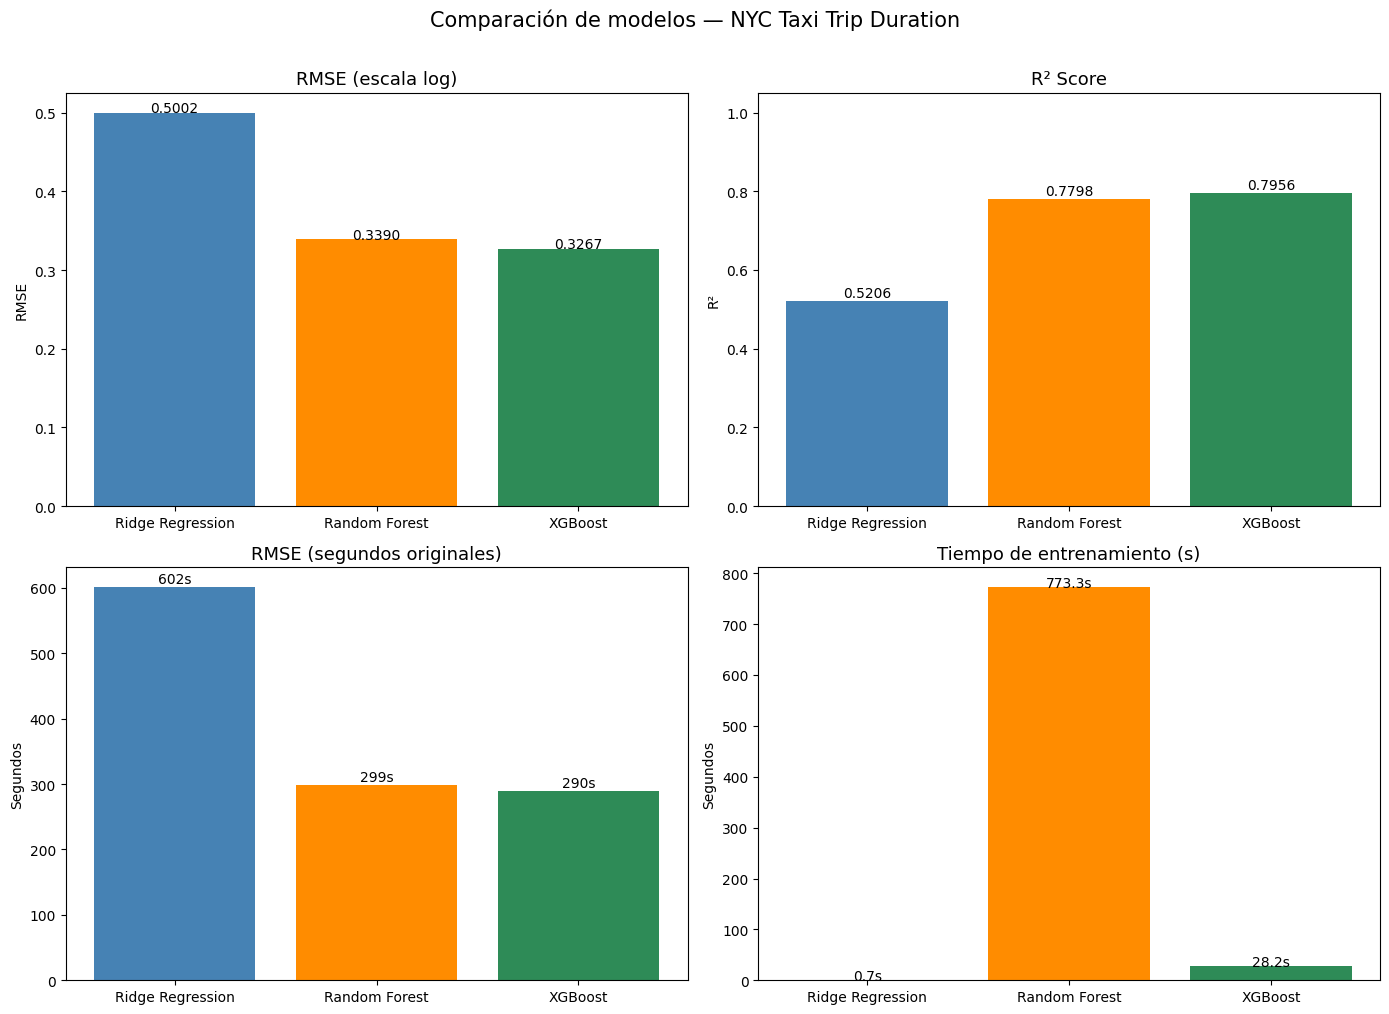

In [35]:
modelos = [r['modelo'] for r in resultados]
rmse_log_vals = [r['RMSE_log'] for r in resultados]
mae_log_vals  = [r['MAE_log']  for r in resultados]
r2_vals       = [r['R2']       for r in resultados]
rmse_seg_vals = [r['RMSE_seg'] for r in resultados]
t_train_vals  = [tiempos[m]['entrenamiento'] for m in ['Ridge', 'RandomForest', 'XGBoost']]

colores = ['steelblue', 'darkorange', 'seagreen']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# RMSE log
axes[0, 0].bar(modelos, rmse_log_vals, color=colores)
axes[0, 0].set_title('RMSE (escala log)', fontsize=13)
axes[0, 0].set_ylabel('RMSE')
for i, v in enumerate(rmse_log_vals):
    axes[0, 0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=10)

# R²
axes[0, 1].bar(modelos, r2_vals, color=colores)
axes[0, 1].set_title('R² Score', fontsize=13)
axes[0, 1].set_ylabel('R²')
axes[0, 1].set_ylim(0, 1.05)
for i, v in enumerate(r2_vals):
    axes[0, 1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)

# RMSE segundos
axes[1, 0].bar(modelos, rmse_seg_vals, color=colores)
axes[1, 0].set_title('RMSE (segundos originales)', fontsize=13)
axes[1, 0].set_ylabel('Segundos')
for i, v in enumerate(rmse_seg_vals):
    axes[1, 0].text(i, v + 5, f'{v:.0f}s', ha='center', fontsize=10)

# Tiempo de entrenamiento
axes[1, 1].bar(modelos, t_train_vals, color=colores)
axes[1, 1].set_title('Tiempo de entrenamiento (s)', fontsize=13)
axes[1, 1].set_ylabel('Segundos')
for i, v in enumerate(t_train_vals):
    axes[1, 1].text(i, v + 0.5, f'{v:.1f}s', ha='center', fontsize=10)

plt.suptitle('Comparación de modelos — NYC Taxi Trip Duration', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Predicción vs Real (mejor modelo)

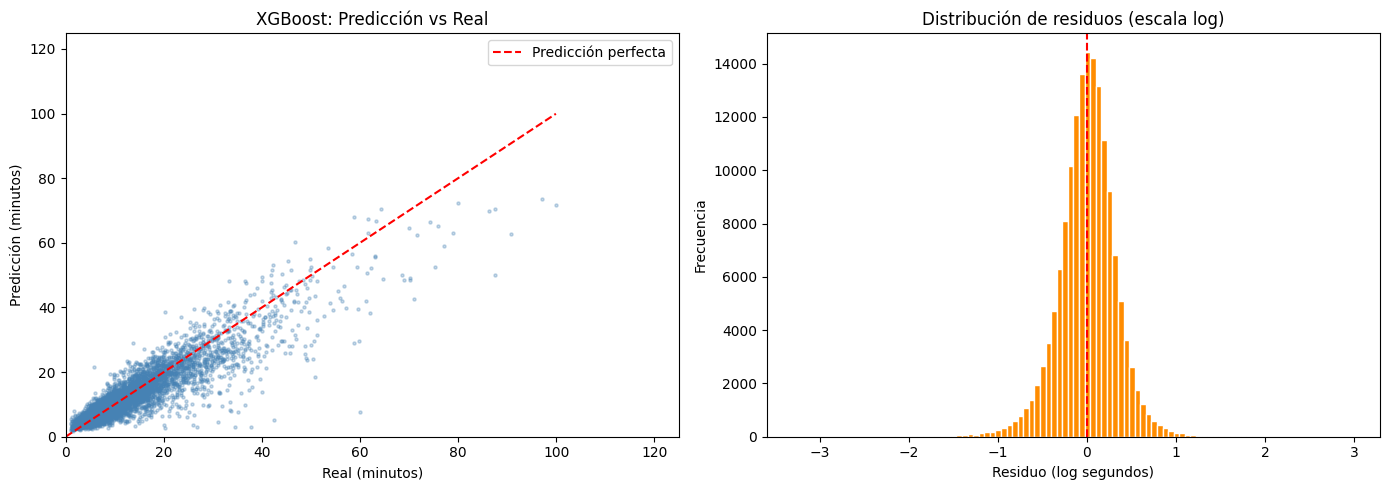

In [36]:
# Usamos XGBoost como mejor modelo esperado
y_true_s  = np.expm1(y_test)
y_pred_s  = np.expm1(np.clip(y_pred_xgb, 0, None))

# Muestra aleatoria para el scatter (graficar todo el dataset sería lento)
idx = np.random.choice(len(y_true_s), size=min(5000, len(y_true_s)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter predicción vs real
axes[0].scatter(y_true_s[idx] / 60, y_pred_s[idx] / 60, alpha=0.3, s=5, color='steelblue')
max_val = max(y_true_s[idx].max(), y_pred_s[idx].max()) / 60
axes[0].plot([0, max_val], [0, max_val], 'r--', lw=1.5, label='Predicción perfecta')
axes[0].set_title('XGBoost: Predicción vs Real')
axes[0].set_xlabel('Real (minutos)')
axes[0].set_ylabel('Predicción (minutos)')
axes[0].legend()
axes[0].set_xlim(0, 125)
axes[0].set_ylim(0, 125)

# Distribución de residuos
residuos = y_pred_xgb - y_test
axes[1].hist(residuos, bins=100, color='darkorange', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_title('Distribución de residuos (escala log)')
axes[1].set_xlabel('Residuo (log segundos)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('pred_vs_real_xgb.png', dpi=150)
plt.show()

## 10. Importancia de características (Random Forest y XGBoost)

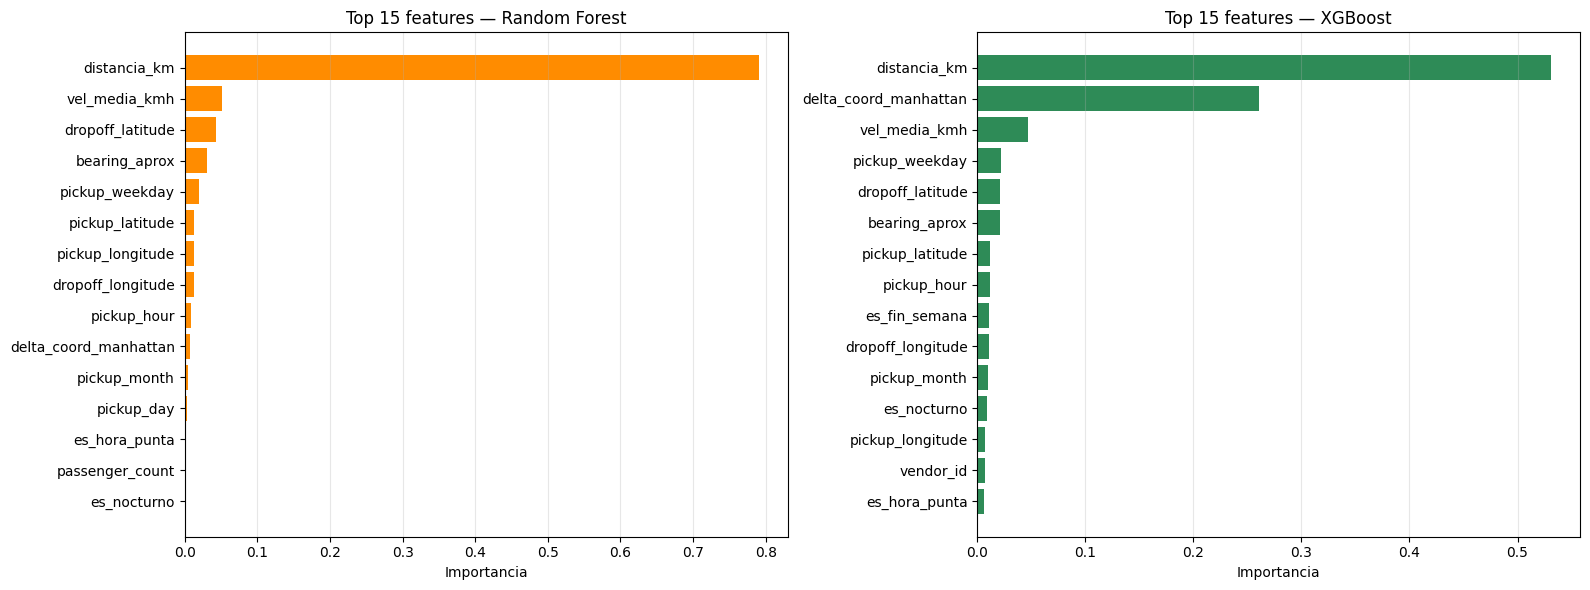

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, importances, nombre, color in zip(
    axes,
    [rf.feature_importances_, xgb_model.feature_importances_],
    ['Random Forest', 'XGBoost'],
    ['darkorange', 'seagreen']
):
    idx_sorted = np.argsort(importances)[::-1]
    top_n = 15
    feat_names = [FEATURE_COLS[i] for i in idx_sorted[:top_n]]
    feat_vals  = importances[idx_sorted[:top_n]]

    ax.barh(feat_names[::-1], feat_vals[::-1], color=color)
    ax.set_title(f'Top {top_n} features — {nombre}', fontsize=12)
    ax.set_xlabel('Importancia')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

## 11. Curva de aprendizaje de XGBoost

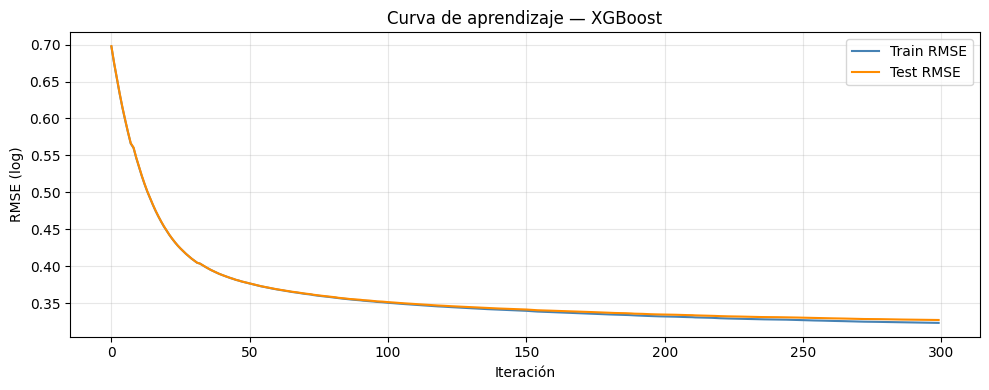

In [38]:
# Reentrenamos con eval_set para guardar la curva
xgb_eval = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    verbosity=0,
    eval_metric='rmse'
)

xgb_eval.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

evals = xgb_eval.evals_result()
train_rmse = evals['validation_0']['rmse']
test_rmse  = evals['validation_1']['rmse']

plt.figure(figsize=(10, 4))
plt.plot(train_rmse, label='Train RMSE', color='steelblue')
plt.plot(test_rmse,  label='Test RMSE',  color='darkorange')
plt.title('Curva de aprendizaje — XGBoost')
plt.xlabel('Iteración')
plt.ylabel('RMSE (log)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('curva_aprendizaje_xgb.png', dpi=150)
plt.show()

## 12. Reporte de tiempos

In [39]:
print('=' * 55)
print('REPORTE DE TIEMPOS')
print('=' * 55)
print(f'  Carga dataset (Polars):          {t_load:.3f} s')
print(f'  Preprocesamiento (Polars→numpy): {t_preproc_polars:.3f} s')
print()
for modelo, t in tiempos.items():
    print(f'  {modelo:<18} entrenamiento: {t["entrenamiento"]:>7.3f} s')
    print(f'  {"":<18} predicción:    {t["prediccion"]:>7.4f} s')
print('=' * 55)

print('\n=== TABLA FINAL DE MÉTRICAS ===')
print(df_resultados.to_pandas().to_string(index=False))

REPORTE DE TIEMPOS
  Carga dataset (Polars):          0.783 s
  Preprocesamiento (Polars→numpy): 0.200 s

  Ridge              entrenamiento:   0.680 s
                     predicción:     0.0420 s
  RandomForest       entrenamiento: 773.315 s
                     predicción:     3.0960 s
  XGBoost            entrenamiento:  28.250 s
                     predicción:     0.9000 s

=== TABLA FINAL DE MÉTRICAS ===
          modelo  RMSE_log  MAE_log     R2  RMSE_seg  MAE_seg  t_entrenamiento_s  t_prediccion_s
Ridge Regression    0.5002   0.3897 0.5206     601.6    318.8              0.680           0.042
   Random Forest    0.3390   0.2510 0.7798     299.2    184.6            773.315           3.096
         XGBoost    0.3267   0.2409 0.7956     289.8    177.1             28.250           0.900


# **Benchmark Polars vs Pandas**

# Instalación e importaciones

In [40]:
import os
import psutil
import tracemalloc

# ── Información del sistema ──────────────────────────────────────────────────
cpu_count  = os.cpu_count()
ram_gb     = psutil.virtual_memory().total / (1024 ** 3)
print(f'\nNúcleos disponibles: {cpu_count}')
print(f'Memoria RAM total:   {ram_gb:.1f} GB')


Núcleos disponibles: 2
Memoria RAM total:   12.7 GB


In [41]:
# Ruta al dataset original (train.csv de Kaggle)
DATA_PATH = '/content/train.csv'

# Tamaño del archivo
file_mb = os.path.getsize(DATA_PATH) / (1024 ** 2)
print(f'Tamaño del dataset: {file_mb:.1f} MB')

# Coordenadas NYC para el filtro
NYC_LON = (-74.05, -73.75)
NYC_LAT = (40.63, 40.85)

Tamaño del dataset: 104.0 MB


# Funcion de memoria

In [42]:
def medir_memoria(fn):
    """Ejecuta fn() y retorna (resultado, tiempo_s, mem_peak_mb)."""
    tracemalloc.start()
    t0 = time.perf_counter()
    resultado = fn()
    t1 = time.perf_counter()
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return resultado, round(t1 - t0, 4), round(peak / (1024 ** 2), 2)

## Pipeline Polars

In [43]:
tiempos_polars = {}

# ── Lectura ──────────────────────────────────────────────────────────────────
_, t, m = medir_memoria(lambda: pl.read_csv(DATA_PATH))
tiempos_polars['lectura'] = t
df_pl = pl.read_csv(DATA_PATH)
print(f'[Polars] Lectura:       {t:.4f}s  |  {m:.1f} MB')

# ── Filtrado ─────────────────────────────────────────────────────────────────
def filtrar_pl():
    return df_pl.filter(
        (pl.col('trip_duration') > 60) & (pl.col('trip_duration') <= 7200)
        & (pl.col('passenger_count') >= 1) & (pl.col('passenger_count') <= 6)
        & pl.col('pickup_longitude').is_between(*NYC_LON)
        & pl.col('pickup_latitude').is_between(*NYC_LAT)
        & pl.col('dropoff_longitude').is_between(*NYC_LON)
        & pl.col('dropoff_latitude').is_between(*NYC_LAT)
    )
df_pl_f, t, m = medir_memoria(filtrar_pl)
tiempos_polars['filtrado'] = t
print(f'[Polars] Filtrado:      {t:.4f}s  |  {m:.1f} MB')

# ── Agregación (group_by) ─────────────────────────────────────────────────────
def agg_pl():
    return df_pl_f.group_by('vendor_id').agg([
        pl.col('trip_duration').mean().alias('dur_media'),
        pl.col('trip_duration').std().alias('dur_std'),
        pl.len().alias('n_viajes'),
    ])
_, t, m = medir_memoria(agg_pl)
tiempos_polars['agregacion'] = t
print(f'[Polars] Agregación:    {t:.4f}s  |  {m:.1f} MB')

# ── Join ─────────────────────────────────────────────────────────────────────
vendor_info = pl.DataFrame({'vendor_id': [1, 2], 'vendor_name': ['CMT', 'VTS']})
def join_pl():
    return df_pl_f.join(vendor_info, on='vendor_id', how='left')
df_pl_j, t, m = medir_memoria(join_pl)
tiempos_polars['join'] = t
print(f'[Polars] Join:          {t:.4f}s  |  {m:.1f} MB')

# ── Feature Engineering ───────────────────────────────────────────────────────
def feat_eng_pl():
    return df_pl_j.with_columns([
        pl.col('pickup_datetime').str.to_datetime('%Y-%m-%d %H:%M:%S').alias('pickup_dt'),
    ]).with_columns([
        pl.col('pickup_dt').dt.hour().alias('pickup_hour'),
        pl.col('pickup_dt').dt.weekday().alias('pickup_weekday'),
        pl.col('pickup_dt').dt.month().alias('pickup_month'),
        (
            pl.col('pickup_dt').dt.hour().is_between(7, 9)
            | pl.col('pickup_dt').dt.hour().is_between(17, 19)
        ).cast(pl.Int8).alias('es_hora_punta'),
        (pl.col('pickup_dt').dt.weekday() >= 5).cast(pl.Int8).alias('es_fin_semana'),
        # Distancia Haversine
        (
            2 * 6371 * (
                (
                    ((pl.col('dropoff_latitude') - pl.col('pickup_latitude')) * np.pi / 180 / 2).sin() ** 2
                    + pl.col('pickup_latitude').radians().cos()
                    * pl.col('dropoff_latitude').radians().cos()
                    * ((pl.col('dropoff_longitude') - pl.col('pickup_longitude')) * np.pi / 180 / 2).sin() ** 2
                ).sqrt().arcsin()
            )
        ).alias('distancia_km'),
        pl.col('trip_duration').log1p().alias('log_trip_duration'),
        (pl.col('store_and_fwd_flag') == 'Y').cast(pl.Int8).alias('flag_enc'),
    ])
df_pl_fe, t, m = medir_memoria(feat_eng_pl)
tiempos_polars['feature_engineering'] = t
print(f'[Polars] Feature Eng:   {t:.4f}s  |  {m:.1f} MB')

tiempos_polars['total'] = sum(tiempos_polars.values())
print(f'\n[Polars] TOTAL:         {tiempos_polars["total"]:.4f}s')

[Polars] Lectura:       0.9073s  |  4.2 MB
[Polars] Filtrado:      0.0674s  |  0.0 MB
[Polars] Agregación:    0.0799s  |  0.0 MB
[Polars] Join:          0.0214s  |  0.0 MB
[Polars] Feature Eng:   0.2989s  |  0.0 MB

[Polars] TOTAL:         1.3749s


## Pipeline Pandas (mismo pipeline)

In [46]:
import pandas as pd

tiempos_pandas = {}

# ── Lectura ──────────────────────────────────────────────────────────────────
_, t, m = medir_memoria(lambda: pd.read_csv(DATA_PATH))
tiempos_pandas['lectura'] = t
df_pd = pd.read_csv(DATA_PATH)
print(f'[Pandas] Lectura:       {t:.4f}s  |  {m:.1f} MB')

# ── Filtrado ─────────────────────────────────────────────────────────────────
def filtrar_pd():
    mask = (
        (df_pd['trip_duration'] > 60) & (df_pd['trip_duration'] <= 7200)
        & (df_pd['passenger_count'] >= 1) & (df_pd['passenger_count'] <= 6)
        & df_pd['pickup_longitude'].between(*NYC_LON)
        & df_pd['pickup_latitude'].between(*NYC_LAT)
        & df_pd['dropoff_longitude'].between(*NYC_LON)
        & df_pd['dropoff_latitude'].between(*NYC_LAT)
    )
    return df_pd[mask].copy()
df_pd_f, t, m = medir_memoria(filtrar_pd)
tiempos_pandas['filtrado'] = t
print(f'[Pandas] Filtrado:      {t:.4f}s  |  {m:.1f} MB')

# ── Agregación (groupby) ──────────────────────────────────────────────────────
def agg_pd():
    return df_pd_f.groupby('vendor_id')['trip_duration'].agg(['mean', 'std', 'count'])
_, t, m = medir_memoria(agg_pd)
tiempos_pandas['agregacion'] = t
print(f'[Pandas] Agregación:    {t:.4f}s  |  {m:.1f} MB')

# ── Join (merge) ──────────────────────────────────────────────────────────────
vendor_info_pd = pd.DataFrame({'vendor_id': [1, 2], 'vendor_name': ['CMT', 'VTS']})
def join_pd():
    return df_pd_f.merge(vendor_info_pd, on='vendor_id', how='left')
df_pd_j, t, m = medir_memoria(join_pd)
tiempos_pandas['join'] = t
print(f'[Pandas] Join:          {t:.4f}s  |  {m:.1f} MB')

# ── Feature Engineering ───────────────────────────────────────────────────────
def feat_eng_pd():
    df = df_pd_j.copy()
    df['pickup_dt'] = pd.to_datetime(df['pickup_datetime'])
    df['pickup_hour']    = df['pickup_dt'].dt.hour
    df['pickup_weekday'] = df['pickup_dt'].dt.dayofweek
    df['pickup_month']   = df['pickup_dt'].dt.month
    df['es_hora_punta']  = (
        df['pickup_hour'].between(7, 9) | df['pickup_hour'].between(17, 19)
    ).astype(int)
    df['es_fin_semana']  = (df['pickup_weekday'] >= 5).astype(int)
    # Haversine
    R = 6371
    lat1 = np.radians(df['pickup_latitude'].values)
    lat2 = np.radians(df['dropoff_latitude'].values)
    dlat = lat2 - lat1
    dlon = np.radians(df['dropoff_longitude'].values - df['pickup_longitude'].values)
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    df['distancia_km']      = 2 * R * np.arcsin(np.sqrt(a))
    df['log_trip_duration'] = np.log1p(df['trip_duration'])
    df['flag_enc']          = (df['store_and_fwd_flag'] == 'Y').astype(int)
    return df
df_pd_fe, t, m = medir_memoria(feat_eng_pd)
tiempos_pandas['feature_engineering'] = t
print(f'[Pandas] Feature Eng:   {t:.4f}s  |  {m:.1f} MB')

tiempos_pandas['total'] = sum(tiempos_pandas.values())
print(f'\n[Pandas] TOTAL:         {tiempos_pandas["total"]:.4f}s')

[Pandas] Lectura:       6.6672s  |  352.2 MB
[Pandas] Filtrado:      0.2171s  |  137.1 MB
[Pandas] Agregación:    0.0502s  |  22.1 MB
[Pandas] Join:          0.1396s  |  83.0 MB
[Pandas] Feature Eng:   1.1559s  |  151.2 MB

[Pandas] TOTAL:         8.2300s


## Tabla comparativa

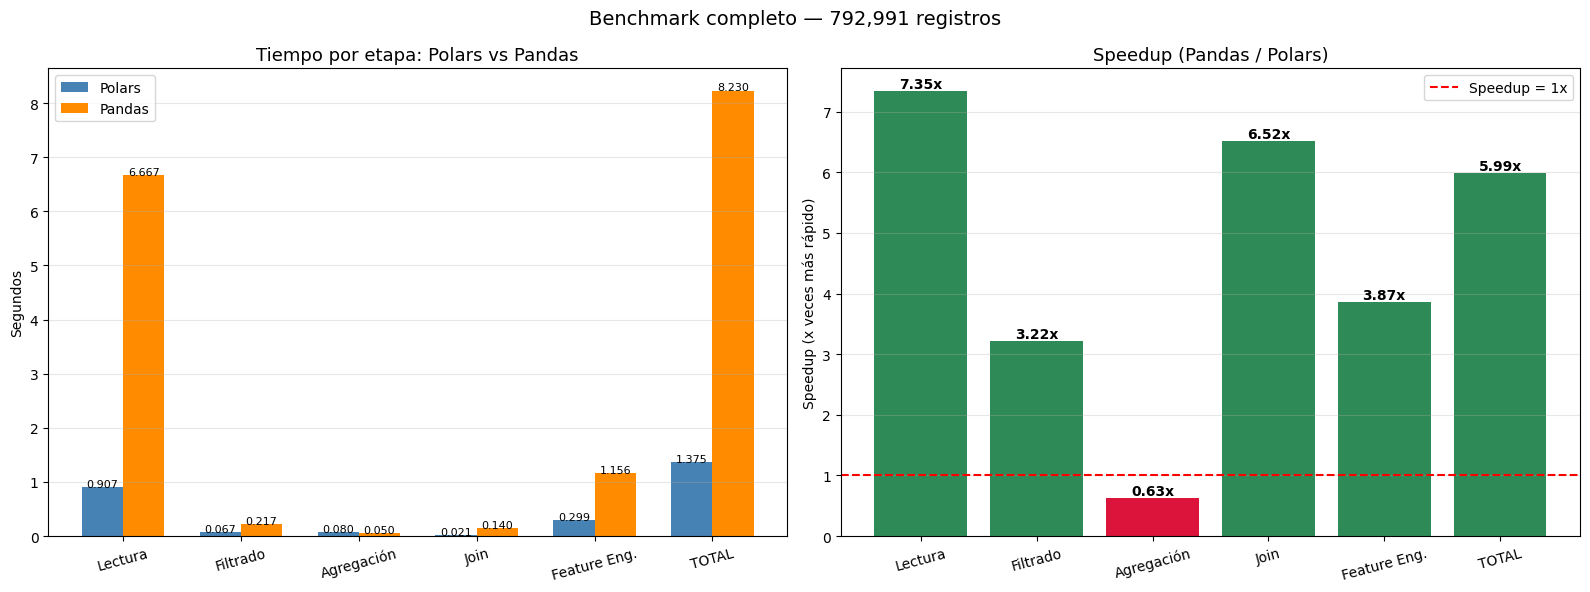

In [49]:
etapas_labels = ['Lectura', 'Filtrado', 'Agregación', 'Join', 'Feature Eng.', 'TOTAL']
polars_keys = ['lectura', 'filtrado', 'agregacion', 'join', 'feature_engineering', 'total']

p_times_list = [tiempos_polars[k] for k in polars_keys]
pd_times_list = [tiempos_pandas[k] for k in polars_keys]
speedups_list = [pd_t / p_t if p_t != 0 else np.nan for pd_t, p_t in zip(pd_times_list, p_times_list)] # Evitar división por cero

df_bench = pl.DataFrame({
    'etapa': etapas_labels,
    'polars_s': p_times_list,
    'pandas_s': pd_times_list,
    'speedup_x': speedups_list
})

p_times = df_bench['polars_s'].to_list()
pd_times = df_bench['pandas_s'].to_list()
speedups = df_bench['speedup_x'].to_list()

x = np.arange(len(etapas_labels))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barras agrupadas de tiempos
bars1 = axes[0].bar(x - w/2, p_times,  w, label='Polars', color='steelblue')
bars2 = axes[0].bar(x + w/2, pd_times, w, label='Pandas', color='darkorange')
axes[0].set_title('Tiempo por etapa: Polars vs Pandas', fontsize=13)
axes[0].set_ylabel('Segundos')
axes[0].set_xticks(x)
axes[0].set_xticklabels(etapas_labels, rotation=15)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for bar in bars1:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.002, f'{h:.3f}', ha='center', fontsize=8)
for bar in bars2:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.002, f'{h:.3f}', ha='center', fontsize=8)

# Speedup
colors_sp = ['seagreen' if s >= 1 else 'crimson' for s in speedups]
bars3 = axes[1].bar(etapas_labels, speedups, color=colors_sp)
axes[1].axhline(1, color='red', linestyle='--', lw=1.5, label='Speedup = 1x')
axes[1].set_title('Speedup (Pandas / Polars)', fontsize=13)
axes[1].set_ylabel('Speedup (x veces más rápido)')
axes[1].set_xticklabels(etapas_labels, rotation=15)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
for bar, v in zip(bars3, speedups):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.05, f'{v:.2f}x', ha='center', fontsize=10, fontweight='bold')

plt.suptitle(f'Benchmark completo — {df_pl.shape[0]:,} registros', fontsize=14)
plt.tight_layout()
plt.savefig('benchmark_polars_pandas.png', dpi=150, bbox_inches='tight')
plt.show()


# Parte 7: Experimentos

## Escalabilidad con tamaño de datos (25 %, 50 %, 75 %, 100 %)

In [50]:
# Cargamos el dataset completo una sola vez
df_full_pl = pl.read_csv(DATA_PATH)
df_full_pd = pd.read_csv(DATA_PATH)
N = df_full_pl.shape[0]
print(f'Total registros: {N:,}')

fracciones   = [0.25, 0.50, 0.75, 1.00]
resultados_escala = []

def pipeline_polars_completo(df_sub: pl.DataFrame) -> float:
    """Pipeline completo en Polars y retorna tiempo total."""
    t0 = time.perf_counter()
    result = (
        df_sub
        .filter(
            (pl.col('trip_duration') > 60) & (pl.col('trip_duration') <= 7200)
            & (pl.col('passenger_count') >= 1) & (pl.col('passenger_count') <= 6)
            & pl.col('pickup_longitude').is_between(*NYC_LON)
            & pl.col('pickup_latitude').is_between(*NYC_LAT)
            & pl.col('dropoff_longitude').is_between(*NYC_LON)
            & pl.col('dropoff_latitude').is_between(*NYC_LAT)
        )
        .with_columns([
            pl.col('pickup_datetime').str.to_datetime('%Y-%m-%d %H:%M:%S').alias('pickup_dt'),
        ])
        .with_columns([
            pl.col('pickup_dt').dt.hour().alias('pickup_hour'),
            pl.col('pickup_dt').dt.weekday().alias('pickup_weekday'),
            pl.col('pickup_dt').dt.month().alias('pickup_month'),
            (
                pl.col('pickup_dt').dt.hour().is_between(7, 9)
                | pl.col('pickup_dt').dt.hour().is_between(17, 19)
            ).cast(pl.Int8).alias('es_hora_punta'),
            (
                2 * 6371 * (
                    (
                        ((pl.col('dropoff_latitude') - pl.col('pickup_latitude')) * np.pi / 180 / 2).sin() ** 2
                        + pl.col('pickup_latitude').radians().cos()
                        * pl.col('dropoff_latitude').radians().cos()
                        * ((pl.col('dropoff_longitude') - pl.col('pickup_longitude')) * np.pi / 180 / 2).sin() ** 2
                    ).sqrt().arcsin()
                )
            ).alias('distancia_km'),
            pl.col('trip_duration').log1p().alias('log_trip_duration'),
        ])
        .group_by('pickup_hour')
        .agg(pl.col('distancia_km').mean().alias('dist_media_hora'))
    )
    return time.perf_counter() - t0


def pipeline_pandas_completo(df_sub: pd.DataFrame) -> float:
    """Pipeline completo en Pandas y retorna tiempo total."""
    t0 = time.perf_counter()
    mask = (
        (df_sub['trip_duration'] > 60) & (df_sub['trip_duration'] <= 7200)
        & (df_sub['passenger_count'] >= 1) & (df_sub['passenger_count'] <= 6)
        & df_sub['pickup_longitude'].between(*NYC_LON)
        & df_sub['pickup_latitude'].between(*NYC_LAT)
        & df_sub['dropoff_longitude'].between(*NYC_LON)
        & df_sub['dropoff_latitude'].between(*NYC_LAT)
    )
    df_f = df_sub[mask].copy()
    df_f['pickup_dt']      = pd.to_datetime(df_f['pickup_datetime'])
    df_f['pickup_hour']    = df_f['pickup_dt'].dt.hour
    df_f['pickup_weekday'] = df_f['pickup_dt'].dt.dayofweek
    df_f['pickup_month']   = df_f['pickup_dt'].dt.month
    df_f['es_hora_punta']  = (
        df_f['pickup_hour'].between(7, 9) | df_f['pickup_hour'].between(17, 19)
    ).astype(int)
    R = 6371
    lat1 = np.radians(df_f['pickup_latitude'].values)
    lat2 = np.radians(df_f['dropoff_latitude'].values)
    dlat = lat2 - lat1
    dlon = np.radians(df_f['dropoff_longitude'].values - df_f['pickup_longitude'].values)
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    df_f['distancia_km']      = 2 * R * np.arcsin(np.sqrt(a))
    df_f['log_trip_duration'] = np.log1p(df_f['trip_duration'])
    result = df_f.groupby('pickup_hour')['distancia_km'].mean()
    return time.perf_counter() - t0


print('Ejecutando experimento de escalabilidad (3 repeticiones por fracción)...')
N_REPS = 3

for frac in fracciones:
    n_rows = int(N * frac)
    sub_pl = df_full_pl.sample(n=n_rows, seed=42)
    sub_pd = df_full_pd.sample(n=n_rows, random_state=42)

    t_pl_reps  = [pipeline_polars_completo(sub_pl)  for _ in range(N_REPS)]
    t_pd_reps  = [pipeline_pandas_completo(sub_pd)  for _ in range(N_REPS)]

    t_pl  = np.mean(t_pl_reps)
    t_pd  = np.mean(t_pd_reps)
    speedup = t_pd / t_pl

    resultados_escala.append({
        'fraccion':  frac,
        'n_filas':   n_rows,
        'polars_s':  round(t_pl, 4),
        'pandas_s':  round(t_pd, 4),
        'speedup_x': round(speedup, 2),
    })
    print(f'  {int(frac*100):3d}% ({n_rows:,} filas) '
          f'| Polars: {t_pl:.4f}s | Pandas: {t_pd:.4f}s | Speedup: {speedup:.2f}x')

df_escala = pl.DataFrame(resultados_escala)
print('\n=== TABLA DE ESCALABILIDAD ===')
print(df_escala)

Total registros: 792,991
Ejecutando experimento de escalabilidad (3 repeticiones por fracción)...
   25% (198,247 filas) | Polars: 0.1068s | Pandas: 0.2120s | Speedup: 1.98x
   50% (396,495 filas) | Polars: 0.1682s | Pandas: 0.5289s | Speedup: 3.14x
   75% (594,743 filas) | Polars: 0.2632s | Pandas: 0.6089s | Speedup: 2.31x
  100% (792,991 filas) | Polars: 0.3059s | Pandas: 0.8145s | Speedup: 2.66x

=== TABLA DE ESCALABILIDAD ===
shape: (4, 5)
┌──────────┬─────────┬──────────┬──────────┬───────────┐
│ fraccion ┆ n_filas ┆ polars_s ┆ pandas_s ┆ speedup_x │
│ ---      ┆ ---     ┆ ---      ┆ ---      ┆ ---       │
│ f64      ┆ i64     ┆ f64      ┆ f64      ┆ f64       │
╞══════════╪═════════╪══════════╪══════════╪═══════════╡
│ 0.25     ┆ 198247  ┆ 0.1068   ┆ 0.212    ┆ 1.98      │
│ 0.5      ┆ 396495  ┆ 0.1682   ┆ 0.5289   ┆ 3.14      │
│ 0.75     ┆ 594743  ┆ 0.2632   ┆ 0.6089   ┆ 2.31      │
│ 1.0      ┆ 792991  ┆ 0.3059   ┆ 0.8145   ┆ 2.66      │
└──────────┴─────────┴──────────┴──────

##  Gráficas de escalabilidad

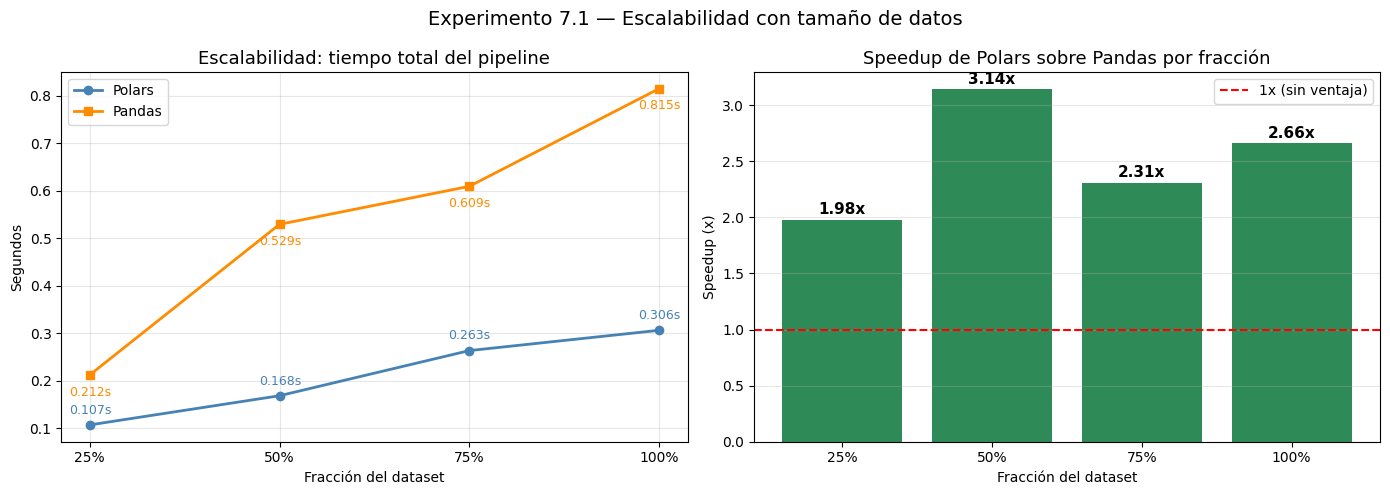

In [51]:
escala_pd = df_escala.to_pandas()
pcts = [f'{int(f*100)}%' for f in fracciones]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tiempos
axes[0].plot(pcts, escala_pd['polars_s'],  marker='o', color='steelblue',  lw=2, label='Polars')
axes[0].plot(pcts, escala_pd['pandas_s'],  marker='s', color='darkorange', lw=2, label='Pandas')
axes[0].set_title('Escalabilidad: tiempo total del pipeline', fontsize=13)
axes[0].set_xlabel('Fracción del dataset')
axes[0].set_ylabel('Segundos')
axes[0].legend()
axes[0].grid(alpha=0.3)
for i, (p, t1, t2) in enumerate(zip(pcts, escala_pd['polars_s'], escala_pd['pandas_s'])):
    axes[0].annotate(f'{t1:.3f}s', (i, t1), textcoords='offset points', xytext=(-15, 8),  fontsize=9, color='steelblue')
    axes[0].annotate(f'{t2:.3f}s', (i, t2), textcoords='offset points', xytext=(-15, -15), fontsize=9, color='darkorange')

# Speedup
axes[1].bar(pcts, escala_pd['speedup_x'], color='seagreen')
axes[1].axhline(1, color='red', linestyle='--', lw=1.5, label='1x (sin ventaja)')
axes[1].set_title('Speedup de Polars sobre Pandas por fracción', fontsize=13)
axes[1].set_xlabel('Fracción del dataset')
axes[1].set_ylabel('Speedup (x)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(escala_pd['speedup_x']):
    axes[1].text(i, v + 0.05, f'{v:.2f}x', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Experimento 7.1 — Escalabilidad con tamaño de datos', fontsize=14)
plt.tight_layout()
plt.savefig('escalabilidad.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7.2 Lazy Execution: `read_csv` vs `scan_csv().collect()`

In [52]:
N_REPS = 5
resultados_lazy = []

# ── Experimento A: Carga completa con read_csv (Eager) ────────────────────────
def eager_pipeline():
    df = pl.read_csv(DATA_PATH)
    return (
        df
        .filter(
            (pl.col('trip_duration') > 60) & (pl.col('trip_duration') <= 7200)
            & pl.col('pickup_longitude').is_between(*NYC_LON)
            & pl.col('pickup_latitude').is_between(*NYC_LAT)
        )
        .with_columns([
            pl.col('pickup_datetime').str.to_datetime('%Y-%m-%d %H:%M:%S').alias('pickup_dt'),
        ])
        .with_columns([
            pl.col('pickup_dt').dt.hour().alias('pickup_hour'),
        ])
        .group_by('pickup_hour')
        .agg(pl.col('trip_duration').mean())
    )

# ── Experimento B: Lazy con scan_csv().collect() ──────────────────────────────
def lazy_pipeline():
    return (
        pl.scan_csv(DATA_PATH)
        .filter(
            (pl.col('trip_duration') > 60) & (pl.col('trip_duration') <= 7200)
            & pl.col('pickup_longitude').is_between(*NYC_LON)
            & pl.col('pickup_latitude').is_between(*NYC_LAT)
        )
        .with_columns([
            pl.col('pickup_datetime').str.to_datetime('%Y-%m-%d %H:%M:%S').alias('pickup_dt'),
        ])
        .with_columns([
            pl.col('pickup_dt').dt.hour().alias('pickup_hour'),
        ])
        .group_by('pickup_hour')
        .agg(pl.col('trip_duration').mean())
        .collect()
    )

print(f'Ejecutando {N_REPS} repeticiones de cada modo...')

t_eager_reps = []
m_eager_reps = []
for _ in range(N_REPS):
    _, t, m = medir_memoria(eager_pipeline)
    t_eager_reps.append(t)
    m_eager_reps.append(m)

t_lazy_reps = []
m_lazy_reps = []
for _ in range(N_REPS):
    _, t, m = medir_memoria(lazy_pipeline)
    t_lazy_reps.append(t)
    m_lazy_reps.append(m)

t_eager_mean = np.mean(t_eager_reps)
t_lazy_mean  = np.mean(t_lazy_reps)
m_eager_mean = np.mean(m_eager_reps)
m_lazy_mean  = np.mean(m_lazy_reps)

speedup_lazy = t_eager_mean / t_lazy_mean
ahorro_mem   = m_eager_mean - m_lazy_mean

print(f'\n  Eager (read_csv):          {t_eager_mean:.4f}s  |  Mem peak: {m_eager_mean:.1f} MB')
print(f'  Lazy  (scan_csv+collect):  {t_lazy_mean:.4f}s  |  Mem peak: {m_lazy_mean:.1f} MB')
print(f'  Speedup Lazy vs Eager:     {speedup_lazy:.2f}x')
print(f'  Ahorro de memoria:         {ahorro_mem:.1f} MB')

df_lazy = pl.DataFrame({
    'modo':      ['Eager (read_csv)', 'Lazy (scan_csv+collect)'],
    'tiempo_s':  [round(t_eager_mean, 4), round(t_lazy_mean, 4)],
    'mem_mb':    [round(m_eager_mean, 1), round(m_lazy_mean, 1)],
})
print('\n=== TABLA LAZY EXECUTION ===')
print(df_lazy)

Ejecutando 5 repeticiones de cada modo...

  Eager (read_csv):          0.8590s  |  Mem peak: 0.0 MB
  Lazy  (scan_csv+collect):  0.4780s  |  Mem peak: 0.0 MB
  Speedup Lazy vs Eager:     1.80x
  Ahorro de memoria:         0.0 MB

=== TABLA LAZY EXECUTION ===
shape: (2, 3)
┌─────────────────────────┬──────────┬────────┐
│ modo                    ┆ tiempo_s ┆ mem_mb │
│ ---                     ┆ ---      ┆ ---    │
│ str                     ┆ f64      ┆ f64    │
╞═════════════════════════╪══════════╪════════╡
│ Eager (read_csv)        ┆ 0.859    ┆ 0.0    │
│ Lazy (scan_csv+collect) ┆ 0.478    ┆ 0.0    │
└─────────────────────────┴──────────┴────────┘


## Gráficas Lazy vs Eager

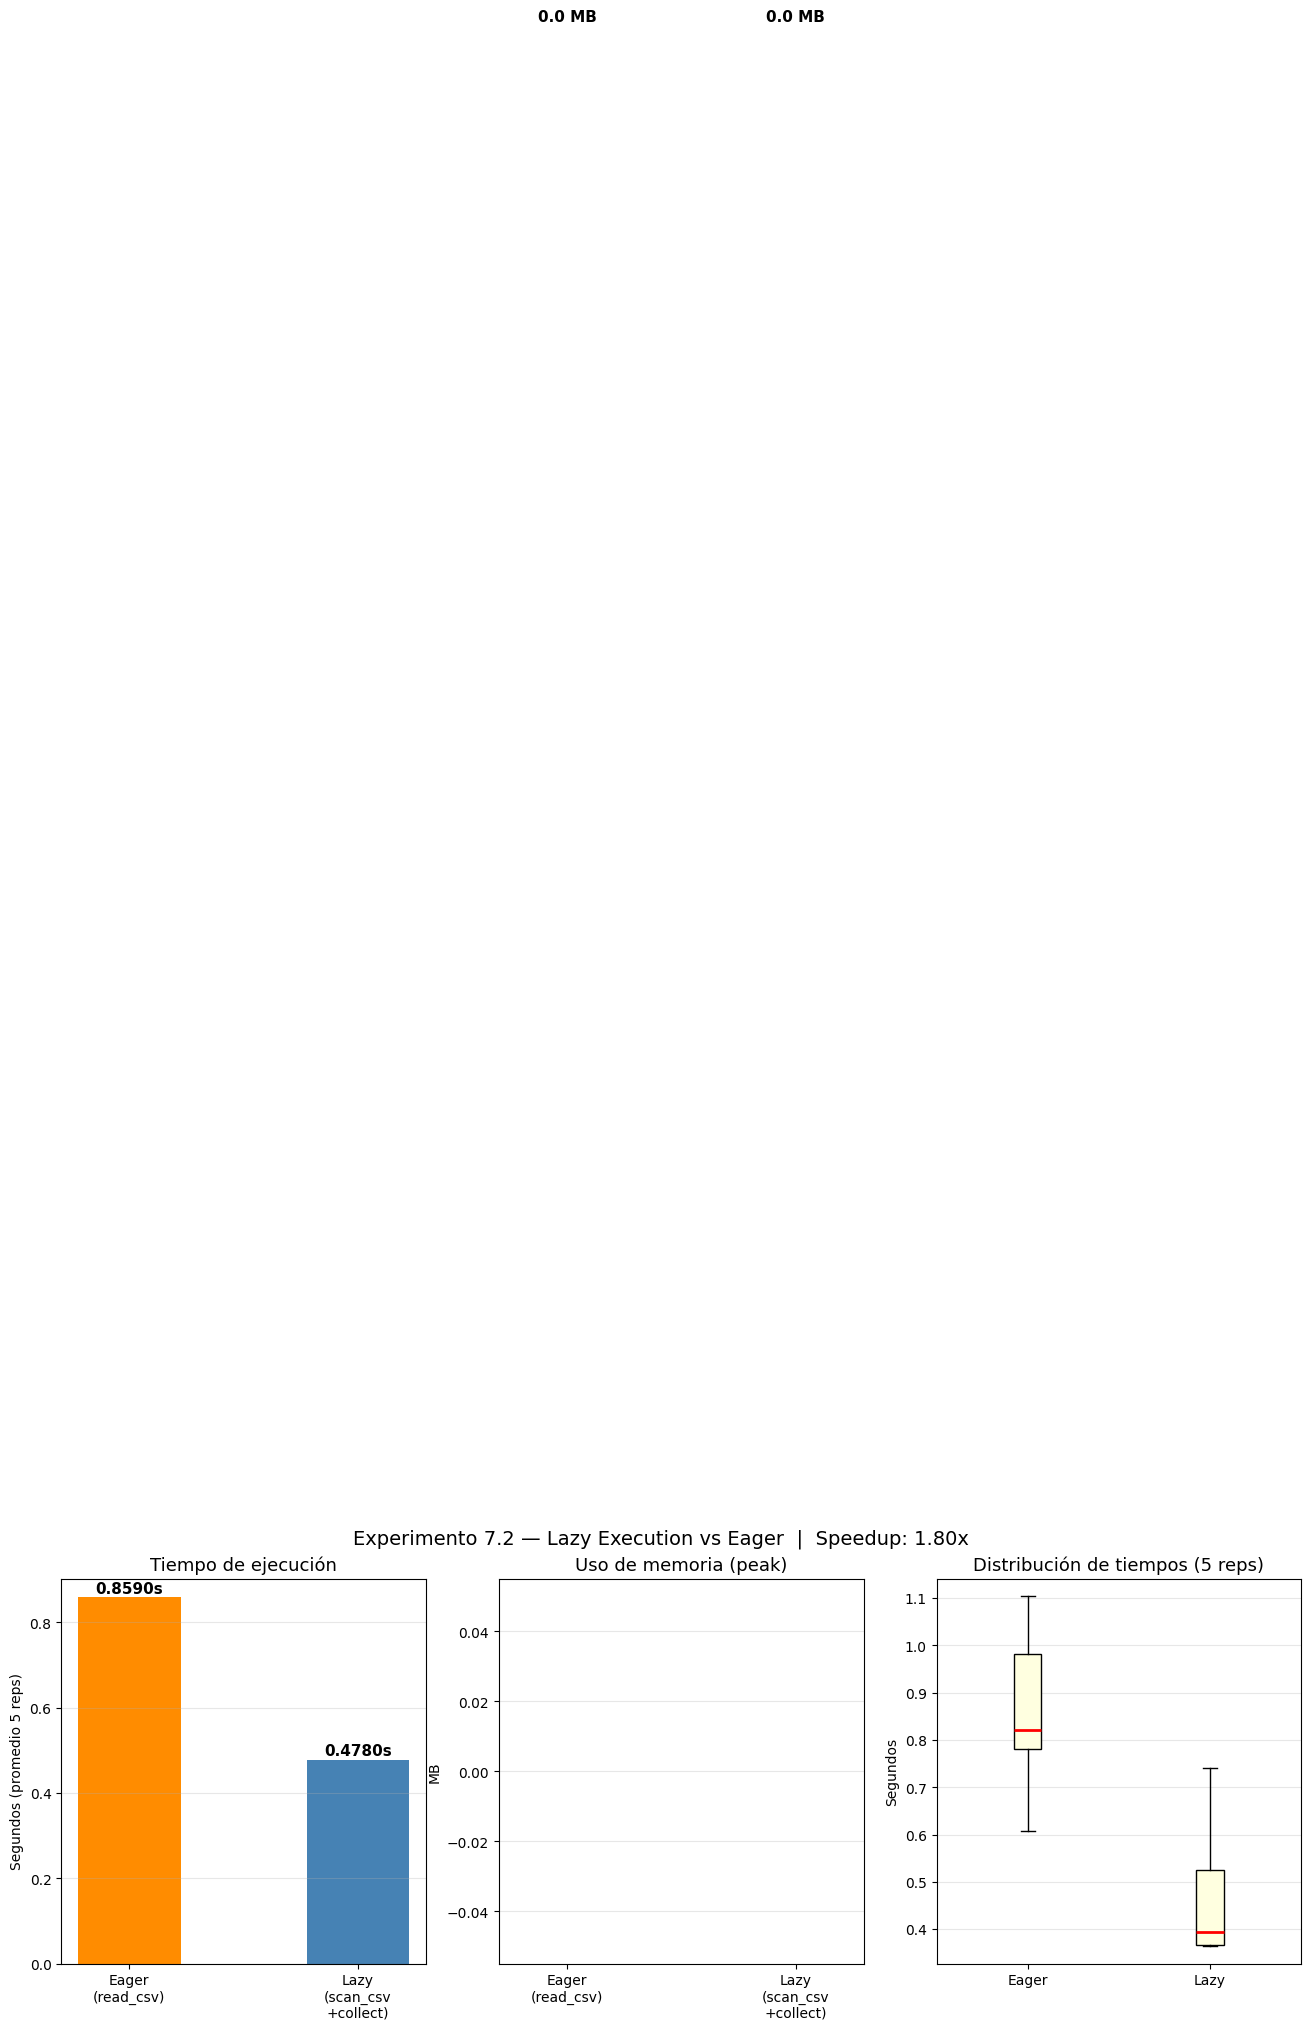

In [53]:
modos   = ['Eager\n(read_csv)', 'Lazy\n(scan_csv\n+collect)']
tiempos_lazy = [t_eager_mean, t_lazy_mean]
memorias_lazy = [m_eager_mean, m_lazy_mean]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Tiempo
bars = axes[0].bar(modos, tiempos_lazy, color=['darkorange', 'steelblue'], width=0.45)
axes[0].set_title('Tiempo de ejecución', fontsize=13)
axes[0].set_ylabel('Segundos (promedio 5 reps)')
axes[0].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, tiempos_lazy):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.4f}s', ha='center', fontsize=11, fontweight='bold')

# Memoria
bars2 = axes[1].bar(modos, memorias_lazy, color=['darkorange', 'steelblue'], width=0.45)
axes[1].set_title('Uso de memoria (peak)', fontsize=13)
axes[1].set_ylabel('MB')
axes[1].grid(axis='y', alpha=0.3)
for bar, v in zip(bars2, memorias_lazy):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f} MB', ha='center', fontsize=11, fontweight='bold')

# Distribución de tiempos individuales
axes[2].boxplot(
    [t_eager_reps, t_lazy_reps],
    labels=['Eager', 'Lazy'],
    patch_artist=True,
    boxprops=dict(facecolor='lightyellow'),
    medianprops=dict(color='red', lw=2)
)
axes[2].set_title(f'Distribución de tiempos ({N_REPS} reps)', fontsize=13)
axes[2].set_ylabel('Segundos')
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle(f'Experimento 7.2 — Lazy Execution vs Eager  |  Speedup: {speedup_lazy:.2f}x', fontsize=14)
plt.tight_layout()
plt.savefig('lazy_vs_eager.png', dpi=150, bbox_inches='tight')
plt.show()

## Resumen final de experimentos

In [54]:
print('=' * 60)
print('RESUMEN GENERAL DE EXPERIMENTOS')
print('=' * 60)
print(f'  Sistema: {cpu_count} núcleos  |  {ram_gb:.1f} GB RAM')
print(f'  Dataset: {N:,} registros  |  {file_mb:.1f} MB')
print()
print('── Benchmark Polars vs Pandas (100 % del dataset) ──')
print(f'  Polars total:  {tiempos_polars["total"]:.4f}s')
print(f'  Pandas total:  {tiempos_pandas["total"]:.4f}s')
print(f'  Speedup total: {tiempos_pandas["total"]/tiempos_polars["total"]:.2f}x')
print()
print('── Escalabilidad ──')
for row in resultados_escala:
    print(f'  {int(row["fraccion"]*100):3d}% ({row["n_filas"]:,} filas): speedup {row["speedup_x"]:.2f}x')
print()
print('── Lazy Execution ──')
print(f'  Eager: {t_eager_mean:.4f}s  |  Lazy: {t_lazy_mean:.4f}s  |  Speedup: {speedup_lazy:.2f}x')
print(f'  Ahorro de memoria: {ahorro_mem:.1f} MB')
print('=' * 60)

RESUMEN GENERAL DE EXPERIMENTOS
  Sistema: 2 núcleos  |  12.7 GB RAM
  Dataset: 792,991 registros  |  104.0 MB

── Benchmark Polars vs Pandas (100 % del dataset) ──
  Polars total:  1.3749s
  Pandas total:  8.2300s
  Speedup total: 5.99x

── Escalabilidad ──
   25% (198,247 filas): speedup 1.98x
   50% (396,495 filas): speedup 3.14x
   75% (594,743 filas): speedup 2.31x
  100% (792,991 filas): speedup 2.66x

── Lazy Execution ──
  Eager: 0.8590s  |  Lazy: 0.4780s  |  Speedup: 1.80x
  Ahorro de memoria: 0.0 MB
